# EDA Q1. Cycle Life 분포

분석 셀은 `use=True`만 쓴다. 제외 셀은 pkl에 남겨 두었다.

- Batch 1: 36/46 (제외 b1c0~b1c4, b1c8, b1c10, b1c12, b1c13, b1c22)
- Batch 2: 39/47 (제외 cycle_life 결측 8셀)
- Batch 3: 44/46 (제외 b3c23, b3c32). b3c37은 유지

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import skew

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import FIGURES_DIR, set_korean_font
from src.preprocess import load_cells

set_korean_font()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 120)

cells = load_cells(usable_only=True)
B1_MAX = float(cells.loc[cells["batch"] == 1, "cycle_life"].max())
COLORS = {1: "#4C72B0", 2: "#DD8452", 3: "#55A868"}
print(cells.groupby("batch").size().rename("n").to_string())
print(f"Batch 1 최대 cycle_life = {B1_MAX:.0f}")

batch
1    36
2    39
3    44
Batch 1 최대 cycle_life = 1074


 batch  n    mean  median    std  skew   min    max  gt_1000  lt_500  ge_550  above_b1_max
     1 36  788.42   772.5 148.70  0.30 534.0 1074.0        5       0      35             0
     2 39  565.74   472.0 222.20  1.64 392.0 1186.0        3      28       9             2
     3 44 1059.66  1005.5 313.87  1.26 541.0 1935.0       23       0      43            16


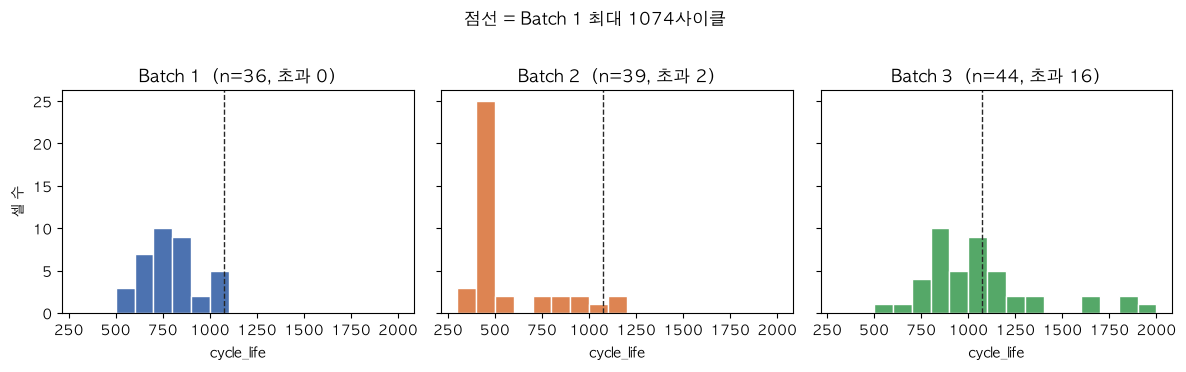

Batch 1 최대(1074) 초과 18셀
cell_id  batch  cycle_life             policy_readable
  b2c34      2      1186.0 5.6C(26%)-4.5C-newstructure
  b2c33      2      1140.0   5.2C(58%)-4C-newstructure
  b3c38      3      1935.0     5C(67%)-4C-newstructure
   b3c7      3      1836.0 4.8C(80%)-4.8C-newstructure
  b3c45      3      1801.0 4.8C(80%)-4.8C-newstructure
  b3c42      3      1642.0 4.8C(80%)-4.8C-newstructure
  b3c16      3      1638.0 4.8C(80%)-4.8C-newstructure
  b3c37      3      1390.0 4.8C(80%)-4.8C-newstructure
  b3c17      3      1315.0   5.3C(54%)-4C-newstructure
  b3c33      3      1284.0     5C(67%)-4C-newstructure
   b3c2      3      1267.0 5.6C(19%)-4.6C-newstructure
  b3c34      3      1158.0   5.3C(54%)-4C-newstructure
  b3c39      3      1156.0   5.3C(54%)-4C-newstructure
  b3c19      3      1155.0 5.6C(36%)-4.3C-newstructure
  b3c18      3      1146.0 5.6C(19%)-4.6C-newstructure
   b3c3      3      1115.0 5.6C(36%)-4.3C-newstructure
  b3c35      3      1093.0 5.6C(19%)-4.6C

In [2]:
def life_summary(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for batch, group in frame.groupby("batch"):
        life = group["cycle_life"].to_numpy(dtype=float)
        rows.append(
            {
                "batch": int(batch),
                "n": life.size,
                "mean": life.mean(),
                "median": float(np.median(life)),
                "std": life.std(ddof=1),
                "skew": float(skew(life, bias=False)),
                "min": life.min(),
                "max": life.max(),
                "gt_1000": int((life > 1000).sum()),
                "lt_500": int((life < 500).sum()),
                "ge_550": int((life >= 550).sum()),
                "above_b1_max": int((life > B1_MAX).sum()),
            }
        )
    return pd.DataFrame(rows)

summary = life_summary(cells)
print(summary.round(2).to_string(index=False))

bins = np.arange(300, 2100, 100)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, batch in zip(axes, (1, 2, 3)):
    life = cells.loc[cells["batch"] == batch, "cycle_life"]
    ax.hist(life, bins=bins, color=COLORS[batch], edgecolor="white")
    ax.axvline(B1_MAX, color="0.15", ls="--", lw=1)
    n_above = int((life > B1_MAX).sum())
    ax.set_title(f"Batch {batch}  (n={life.size}, 초과 {n_above})")
    ax.set_xlabel("cycle_life")
axes[0].set_ylabel("셀 수")
fig.suptitle(f"점선 = Batch 1 최대 {B1_MAX:.0f}사이클", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "q1_cycle_life_hist.png", dpi=150, bbox_inches="tight")
plt.show()

above = cells.loc[cells["cycle_life"] > B1_MAX, ["cell_id", "batch", "cycle_life", "policy_readable"]]
print(f"Batch 1 최대({B1_MAX:.0f}) 초과 {len(above)}셀")
print(above.sort_values(["batch", "cycle_life"], ascending=[True, False]).to_string(index=False))

### 목적
학습에 쓸 Batch 1의 수명 범위 안에 Batch 2·3이 들어오는지, 장수명(>1,000)과 단수명(<500)이 배치마다 어디 몰리는지 확인한다.

### 결과
정제 후 Batch 1 최대는 1,227이 아니다. 1,227은 80%에 도달하지 못해 뺀 b1c4다. 사용 셀의 최대는 **1,074**(b1c5)다.

| 배치 | n | 평균 | 중앙값 | std | 왜도 | 최소 | 최대 | >1,000 | <500 | ≥550 | Batch 1 최대 초과 |
|---|---|---|---|---|---|---|---|---|---|---|---|
| 1 | 36 | 788.4 | 772.5 | 148.7 | 0.30 | 534 | 1074 | 5 (14%) | 0 | 35 (97%) | 0 |
| 2 | 39 | 565.7 | 472.0 | 222.2 | 1.64 | 392 | 1186 | 3 (8%) | 28 (72%) | 9 (23%) | 2 |
| 3 | 44 | 1059.7 | 1005.5 | 313.9 | 1.26 | 541 | 1935 | 23 (52%) | 0 | 43 (98%) | 16 |

Batch 1 최대를 넘는 셀은 Batch 2가 2개(b2c33 1,140, b2c34 1,186), Batch 3가 16개다. 학습 최소 534 미만은 Batch 2가 30/39다. 500 미만 28셀과 다르다. 550 미만은 Batch 1에서 b1c20(534) 하나뿐이고, 이 컷은 분류 라벨로 쓰지 않는다.

### 해석
Batch 2는 고율 충전을 길게 유지하는 프로토콜이 많아 수명 중앙값이 472까지 내려간다. Batch 3는 같은 계열이라도 `newstructure` 셀이 길고, 절반 이상이 1,000사이클을 넘는다. Batch 1에서 1,200대였던 셀은 용량이 0.88Ah까지 내려가기 전에 실험이 끝난 검열 값이라, 학습 데이터가 실제로 본 장수명 상한은 1,074다.

### 시사점 → 모델링
학습 범위 밖 외삽이 필요하다. Batch 2 39셀 중 30셀은 학습 최소(534)보다 짧고, 학습 최대(1,074)를 넘는 셀은 Batch 2가 2개, Batch 3가 16개다. 트리 계열은 학습 때 본 타깃 범위를 넘어 예측하지 못한다. 수명 392인 셀도 534 이상으로만 나오게 된다. 그래서 외삽이 되는 정규화 선형모델(Ridge, Lasso, ElasticNet)을 메인 후보로 두고, 트리·부스팅은 비교군으로 둔다. Hold-out은 36셀의 20%라 약 7셀이고, 충전 정책이 20종이라 그룹 분할 때 셀 수가 더 흔들린다.

Batch 1: fence 395~1157, 이상치 0 (하한 밖 0, 상한 밖 0)
Batch 2: fence 336~612, 이상치 9 (하한 밖 0, 상한 밖 9)
Batch 3: fence 337~1646, 이상치 3 (하한 밖 0, 상한 밖 3)
cell_id  batch  cycle_life             policy_readable
   b2c7      2       777.0 4.8C(80%)-4.8C-newstructure
   b2c9      2       791.0 5.6C(26%)-4.5C-newstructure
  b2c32      2       809.0 4.8C(80%)-4.8C-newstructure
  b2c44      2       841.0   5.2C(58%)-4C-newstructure
   b2c8      2       904.0   5.2C(58%)-4C-newstructure
  b2c45      2       997.0 5.6C(26%)-4.5C-newstructure
  b2c43      2      1029.0 4.8C(80%)-4.8C-newstructure
  b2c33      2      1140.0   5.2C(58%)-4C-newstructure
  b2c34      2      1186.0 5.6C(26%)-4.5C-newstructure
  b3c45      3      1801.0 4.8C(80%)-4.8C-newstructure
   b3c7      3      1836.0 4.8C(80%)-4.8C-newstructure
  b3c38      3      1935.0     5C(67%)-4C-newstructure


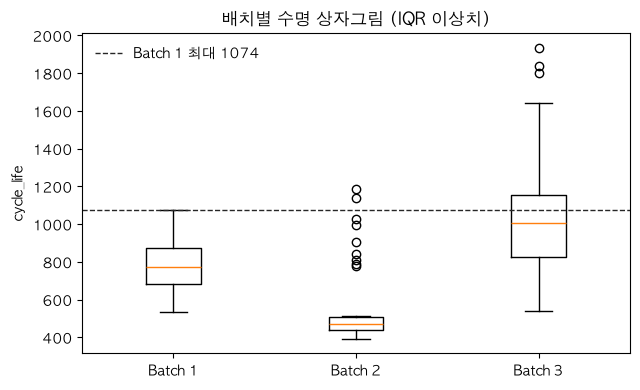

In [3]:
outlier_rows = []
for batch, group in cells.groupby("batch"):
    life = group["cycle_life"]
    q1, q3 = float(life.quantile(0.25)), float(life.quantile(0.75))
    fence = 1.5 * (q3 - q1)
    lo, hi = q1 - fence, q3 + fence
    flagged = group.loc[(life < lo) | (life > hi)].copy()
    flagged["fence_lo"] = lo
    flagged["fence_hi"] = hi
    outlier_rows.append(flagged)
    print(f"Batch {batch}: fence {lo:.0f}~{hi:.0f}, 이상치 {len(flagged)} (하한 밖 {(life < lo).sum()}, 상한 밖 {(life > hi).sum()})")

outliers = pd.concat(outlier_rows, ignore_index=True)
print(outliers.sort_values("cycle_life")[
    ["cell_id", "batch", "cycle_life", "policy_readable"]
].to_string(index=False))

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.boxplot(
    [cells.loc[cells["batch"] == b, "cycle_life"] for b in (1, 2, 3)],
    tick_labels=["Batch 1", "Batch 2", "Batch 3"],
    showfliers=True,
)
ax.axhline(B1_MAX, color="0.15", ls="--", lw=1, label=f"Batch 1 최대 {B1_MAX:.0f}")
ax.set_ylabel("cycle_life")
ax.set_title("배치별 수명 상자그림 (IQR 이상치)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "q1_cycle_life_box.png", dpi=150, bbox_inches="tight")
plt.show()

### 목적
짧은 수명이 고장 난 이상 셀인지, 그 배치의 보통 셀인지 가른다. 이상치면 충전 정책을 같이 본다.

### 결과
하한 밖(유독 짧은) 셀은 세 배치 모두 0개다.

- Batch 1 펜스 395~1,157. 이상치 없음. 가장 짧은 b1c20·b1c21은 5.4C(80%)-5.4C로 534·559사이클이라 펜스 안이다.
- Batch 2 펜스 336~612. 이상치 9개는 전부 상한 밖(777~1,186)이고 정책명에 `newstructure`가 있다. 같은 전류식의 일반 셀 중앙값은 4.8C(80%)-4.8C 492, 5.2C(58%)-4C 483, 5.6C(26%)-4.5C 446이다. `newstructure` 중앙값은 각각 809, 904, 997이다.
- Batch 3 펜스 337~1,646. 상한 밖은 b3c45(1,801), b3c7(1,836, 둘 다 4.8C(80%)-4.8C-newstructure), b3c38(1,935, 5C(67%)-4C-newstructure).

Batch 2에서 실제로 짧은 쪽은 이상치가 아니라 다수다. 최단은 b2c19 6C(60%)-3C 392, b2c6·b2c15 3.6C(9%)-5C 393·396이다.

### 해석
고율 충전을 높은 SOC까지 유지하면 흑연 쪽에 리튬이 석출되고 열이 나며 수명이 400사이클 근처로 모인다. Batch 1에서 8C라도 15%에서 3.6C로 내리는 b1c41은 1,051사이클이다. 피크 전류보다 고율을 유지하는 구간이 길다. `newstructure` 접미사는 Batch 2에만 있지 않다. Batch 1은 0셀, Batch 2는 9셀, Batch 3는 44셀 모두에 붙어 있다. 같은 전류식끼리 수명이 약 2배로 갈라지는 대비는 Batch 2 안에서만 보인다. C-rate 문자열만으로는 설명되지 않는 하위 집단이다.

### 시사점 → 모델링
IQR로 짧은 셀을 지우면 Batch 2의 본체(테스트 분포)를 지운다. 이상치 제거는 하지 않는다. 정책 피처는 C-rate와 전환 SOC만으로 끝내지 않고, Batch 2의 `newstructure` 대비를 Q4에서 다시 확인한다.

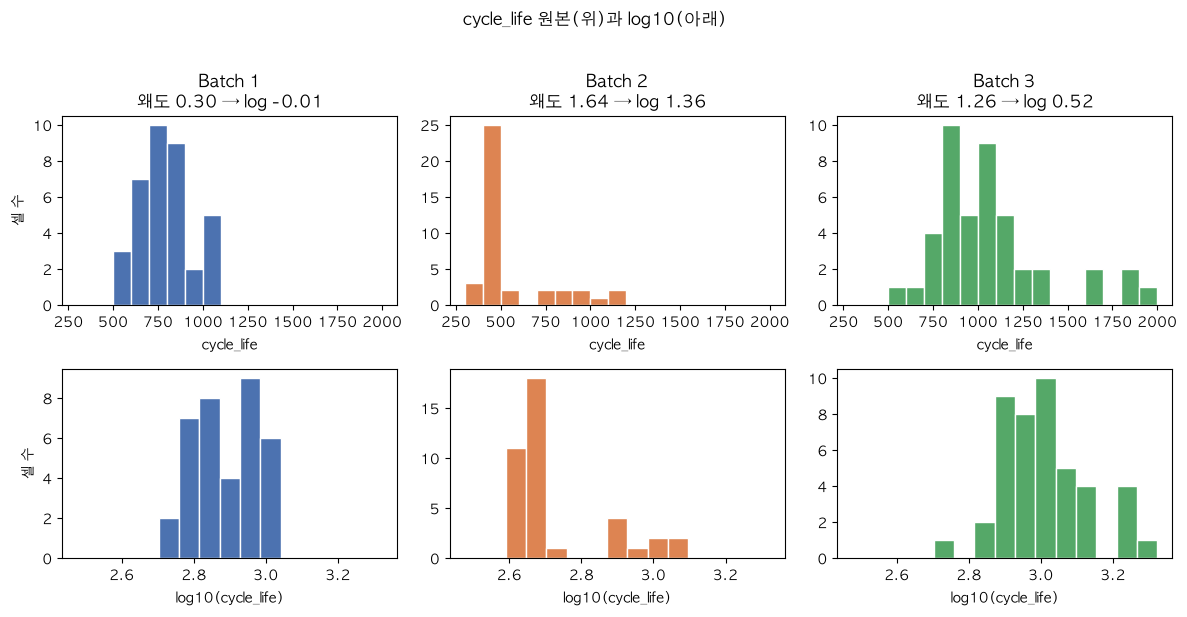

In [4]:
raw_bins = np.arange(300, 2100, 100)
log_bins = np.linspace(np.log10(300), np.log10(2100), 16)
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex="row")
for col, batch in enumerate((1, 2, 3)):
    life = cells.loc[cells["batch"] == batch, "cycle_life"].to_numpy(dtype=float)
    log_life = np.log10(life)
    axes[0, col].hist(life, bins=raw_bins, color=COLORS[batch], edgecolor="white")
    axes[1, col].hist(log_life, bins=log_bins, color=COLORS[batch], edgecolor="white")
    axes[0, col].set_title(
        f"Batch {batch}\n왜도 {skew(life, bias=False):.2f} → log {skew(log_life, bias=False):.2f}"
    )
    axes[0, col].set_xlabel("cycle_life")
    axes[1, col].set_xlabel("log10(cycle_life)")
axes[0, 0].set_ylabel("셀 수")
axes[1, 0].set_ylabel("셀 수")
fig.suptitle("cycle_life 원본(위)과 log10(아래)", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "q1_log10_compare.png", dpi=150, bbox_inches="tight")
plt.show()

### 목적
학습 타깃을 `log10(cycle_life)`로 둘 때 왜도가 얼마나 줄어드는지 확인한다. 이 변환은 확정했다. MAPE는 원래 사이클 수로 계산한다.

### 결과
왜도(원본 → log10): Batch 1은 0.30 → -0.01, Batch 2는 1.64 → 1.36, Batch 3은 1.26 → 0.52.

Batch 1은 원래도 거의 대칭이라 log의 이득이 작다. Batch 3은 오른쪽 꼬리가 분명하게 줄어든다. Batch 2는 log 뒤에도 왜도 1.36이다. 400대에 몰린 일반 셀과 777 이상의 `newstructure` 셀이 갈라져 있어, 로그가 두 집단을 한 봉우리로 만들지 못한다.

### 해석
고율 구간이 길어지면 수명이 대략 절반으로 줄어드는 식의 배수 관계가 있다. 그 차이는 사이클 수 그대로보다 로그 스케일과 더 맞다. 다만 Batch 2의 두 봉우리는 스케일 문제가 아니라 셀 구조가 섞인 문제라, 변환만으로 배치 차이가 사라지지는 않는다.

### 시사점 → 모델링
**확정:** 학습 타깃은 `log10(cycle_life)`, MAPE는 원래 사이클 수로 계산한다. pkl에는 원본 수명을 그대로 둔다.

- 왜도가 Batch 1은 0.30→-0.01, Batch 3은 1.26→0.52로 줄어 긴 수명이 제곱오차를 독점하는 정도가 약해진다.
- MAPE는 상대 오차라 로그 공간의 학습과 평가 목표가 맞다. 원논문도 로그 수명을 쓴다. ΔQ와 로그 수명의 직선 관계는 Q3에서 확인한다.
- 한계: Batch 2 왜도는 1.36으로 남고, 400대 셀과 `newstructure` 장수명의 이봉은 그대로다. 학습 범위 밖 외삽(534 미만 30셀, 1,074 초과 18셀)도 로그로 해결되지 않는다.

## EDA Q2. 열화 곡선

`use=True` 셀만 그린다. Batch 1의 사이클 1은 QD=0인 빈 사이클이라 곡선에서 뺀다. Batch 2·3의 사이클 1은 실제 방전이라 남긴다. 가로 점선은 EOL 기준 0.88Ah다.


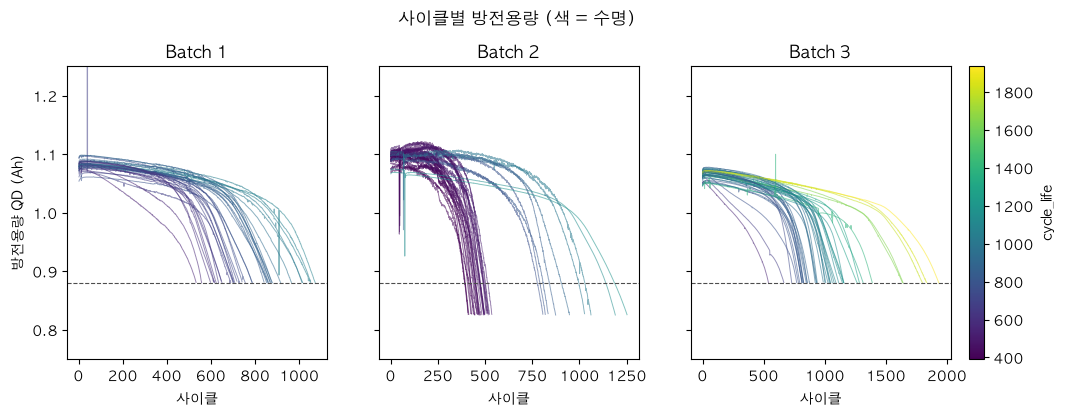

곡선 셀 수 119, Batch 1 사이클 1 QD=0 제거


In [5]:
import pickle

def cell_qd(cell_id: str) -> pd.DataFrame:
    """사이클 1이면서 QD가 0인 자리표시 행을 제거한 QD 곡선."""
    curve = summary.loc[summary["cell_id"] == cell_id, ["cycle", "QD"]].sort_values("cycle")
    return curve.loc[~((curve["cycle"] == 1) & (curve["QD"] == 0))]


parts = []
for batch_id in (1, 2, 3):
    with (ROOT / "data" / "processed" / f"batch{batch_id}.pkl").open("rb") as handle:
        parts.append(pickle.load(handle)["summary"])
summary = pd.concat(parts, ignore_index=True)
summary = summary.loc[summary["cell_id"].isin(set(cells["cell_id"]))]

life_min = float(cells["cycle_life"].min())
life_max = float(cells["cycle_life"].max())
norm = plt.Normalize(life_min, life_max)
cmap = plt.cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, batch in zip(axes, (1, 2, 3)):
    ids = cells.loc[cells["batch"] == batch, "cell_id"]
    for cell_id in ids:
        curve = cell_qd(cell_id)
        life = float(cells.loc[cells["cell_id"] == cell_id, "cycle_life"].iloc[0])
        ax.plot(curve["cycle"], curve["QD"], color=cmap(norm(life)), lw=0.7, alpha=0.55)
    ax.axhline(0.88, color="0.3", ls="--", lw=0.8)
    ax.set_ylim(0.75, 1.25)
    ax.set_title(f"Batch {batch}")
    ax.set_xlabel("사이클")
axes[0].set_ylabel("방전용량 QD (Ah)")
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, label="cycle_life", fraction=0.03, pad=0.02)
fig.suptitle("사이클별 방전용량 (색 = 수명)", y=1.03)
fig.savefig(FIGURES_DIR / "q2_qd_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"곡선 셀 수 {summary['cell_id'].nunique()}, Batch 1 사이클 1 QD=0 제거")


### 목적
수명 차이가 방전용량 곡선 어디에 나타나는지, 배치마다 열화가 처음부터 갈라지는지 본다.

### 결과
세 배치 모두 초반 QD는 1.05~1.11Ah에 겹치고, 0.88Ah로 내려가는 속도만 다르다. y축은 0.75~1.25Ah로 잘랐다. b1c18의 사이클 40 QD가 2.88Ah로 한 점만 튀고 바로 1.07Ah로 돌아오는데, 공칭 1.1Ah 셀에서는 불가능한 값이라 축에 넣지 않았다. 셀 자체는 빼지 않는다. Batch 2는 400사이클 근처에 이미 0.88Ah에 닿는 셀이 많고, Batch 3는 1,000사이클이 넘어도 1.0Ah 근처에 머무는 셀이 있다. 색이 수명이라, 같은 사이클에서 아래쪽에 있는 곡선이 짧은 셀이다.

### 해석
용량 감소는 처음부터 일정한 기울기가 아니다. 초반에는 셀들이 거의 같은 높이에서 시작하고, 수명 차이는 중후반에 기울기가 가팔라지면서 벌어진다. 고율 충전 셀은 리튬 석출이 누적된 뒤에야 용량이 꺾인다.

### 시사점 → 모델링
초기 구간의 QD 높이만으로 셀을 나누면 수명 정보가 거의 없다. 아래 대표 셀 비교에서 그 차이를 Ah 단위로 확인한다. b1c18 사이클 40의 QD 2.88Ah는 셀을 빼지 않고, 피처 계산 전에 앞뒤 중앙값으로 바꾼다.


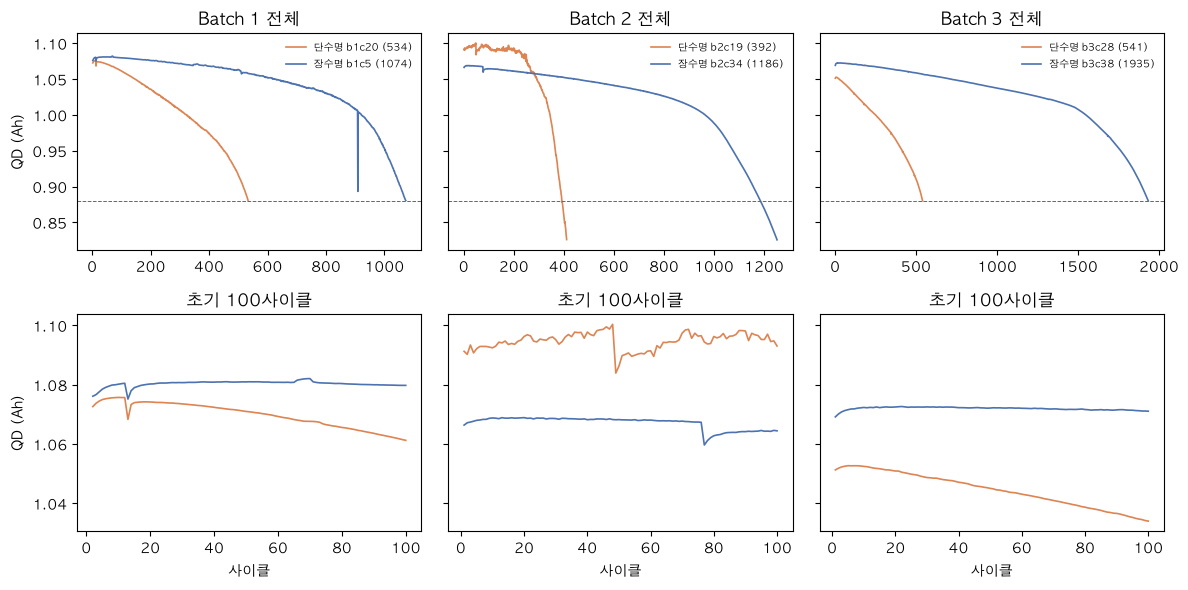

           q100      s100      s400
group                              
long   1.068677 -0.000007 -0.000041
mid    1.076768 -0.000008 -0.000054
short  1.100187  0.000033 -0.000331
Batch 2 사이클 100 QD 중앙값 차이(장수명-단수명) = -0.0315 Ah
전체 사이클 100 QD 범위 = 0.0823 Ah, std = 0.0167


In [6]:
reps = {1: ("b1c20", "b1c5"), 2: ("b2c19", "b2c34"), 3: ("b3c28", "b3c38")}
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey="row")
for col, batch in enumerate((1, 2, 3)):
    short_id, long_id = reps[batch]
    for cell_id, color, name in (
        (short_id, "#DD8452", "단수명"),
        (long_id, "#4C72B0", "장수명"),
    ):
        curve = cell_qd(cell_id)
        life = int(cells.loc[cells["cell_id"] == cell_id, "cycle_life"].iloc[0])
        label = f"{name} {cell_id} ({life})"
        axes[0, col].plot(curve["cycle"], curve["QD"], color=color, lw=1.2, label=label)
        early = curve.loc[curve["cycle"] <= 100]
        axes[1, col].plot(early["cycle"], early["QD"], color=color, lw=1.2, label=label)
    axes[0, col].axhline(0.88, color="0.4", ls="--", lw=0.7)
    axes[0, col].set_title(f"Batch {batch} 전체")
    axes[1, col].set_title("초기 100사이클")
    axes[1, col].set_xlabel("사이클")
    axes[0, col].legend(fontsize=7, frameon=False)
axes[0, 0].set_ylabel("QD (Ah)")
axes[1, 0].set_ylabel("QD (Ah)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "q2_long_short.png", dpi=150, bbox_inches="tight")
plt.show()


def window_slope(curve: pd.DataFrame, lo: int, hi: int) -> float:
    piece = curve.loc[(curve["cycle"] >= lo) & (curve["cycle"] <= hi)]
    if len(piece) < 20:
        return np.nan
    return float(np.polyfit(piece["cycle"].to_numpy(float), piece["QD"].to_numpy(float), 1)[0])


rows = []
for cell_id, curve0 in summary.groupby("cell_id"):
    curve = curve0.sort_values("cycle")
    curve = curve.loc[~((curve["cycle"] == 1) & (curve["QD"] == 0))]
    life = float(cells.loc[cells["cell_id"] == cell_id, "cycle_life"].iloc[0])
    q100 = curve.loc[curve["cycle"] == 100, "QD"]
    rows.append(
        {
            "batch": int(cells.loc[cells["cell_id"] == cell_id, "batch"].iloc[0]),
            "life": life,
            "group": "long" if life > 1000 else ("short" if life < 500 else "mid"),
            "q100": float(q100.iloc[0]),
            "s100": window_slope(curve, 2, 100),
            "s400": window_slope(curve, 100, 400),
        }
    )
fade = pd.DataFrame(rows)
print(fade.groupby("group")[["q100", "s100", "s400"]].median().round(6).to_string())
b2 = fade.loc[fade["batch"] == 2]
diff = b2.loc[b2["group"] == "long", "q100"].median() - b2.loc[b2["group"] == "short", "q100"].median()
print(f"Batch 2 사이클 100 QD 중앙값 차이(장수명-단수명) = {diff:.4f} Ah")
print(f"전체 사이클 100 QD 범위 = {fade['q100'].max() - fade['q100'].min():.4f} Ah, std = {fade['q100'].std():.4f}")


### 목적
장수명과 단수명 셀의 용량 차이가 초기 100사이클에 이미 보이는지, 아니면 그 뒤에 생기는지 수치로 확인한다.

### 결과
대표 셀은 각 배치의 최단·최장이다. Batch 1은 b1c20(534)과 b1c5(1,074), Batch 2는 b2c19(392)와 b2c34(1,186), Batch 3은 b3c28(541)과 b3c38(1,935)다. 전체 곡선에서는 짧은 셀이 먼저 0.88Ah로 떨어지지만, 초기 100사이클에서는 두 선이 겹친다.

그룹 중앙값(장수명 >1,000, 단수명 <500):

| 구간 | 장수명 | 단수명 |
|---|---|---|
| 사이클 100의 QD | 1.069Ah | 1.100Ah |
| 사이클 2~100 기울기 | -0.7e-5 Ah/사이클 | +3.3e-5 Ah/사이클 |
| 사이클 100~400 기울기 | -4.1e-5 Ah/사이클 | -3.3e-4 Ah/사이클 |

Batch 2에서 사이클 100 QD의 장수명−단수명 차이는 -0.032Ah다. 짧은 셀이 오히려 조금 높다. 사용 셀 전체의 사이클 100 QD 범위는 0.082Ah(std 0.017)뿐인데, 수명은 392~1,935사이클이다. 초기 100사이클 기울기를 100사이클 동안 쌓아도 장수명은 0.001Ah 미만, 단수명은 약 0.003Ah라 사실상 평탄하다. 100~400사이클에서는 단수명 기울기가 약 8배 가팔라진다.

### 해석
초기 100사이클의 방전용량은 형성 직후의 용량에 가깝고, 수명을 가르는 가속은 그 뒤에 온다. 짧은 셀이 사이클 100에서 용량이 더 높은 것은 아직 열화가 용량 스칼라에 나타나지 않았기 때문이다. 고율 충전의 손상은 이때 전압 곡선의 모양에는 남지만, 방전 끝 용량(QD 한 점)에는 거의 안 남는다.

### 시사점 → 모델링
초기 100사이클 QD의 평균·기울기만으로는 수명 순서를 만들 수 없다. 그래서 같은 전압에서의 용량 곡선 차이인 ΔQ(V)가 필요하다. Q3에서 사이클 100과 10의 Qdlin 차이를 수명과 비교한다.


knee/life 중앙값 0.779, Pearson 0.994, 후반/전반 기울기 중앙값 10.6


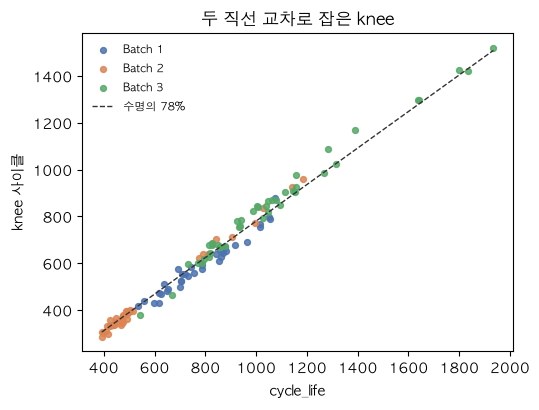

In [7]:
knee_rows = []
for cell_id, curve0 in summary.groupby("cell_id"):
    curve = curve0.sort_values("cycle")
    curve = curve.loc[~((curve["cycle"] == 1) & (curve["QD"] == 0))]
    x = curve["cycle"].to_numpy(float)
    y = curve["QD"].to_numpy(float)
    n = len(x)
    best_sse, knee, slope_before, slope_after = np.inf, np.nan, np.nan, np.nan
    for index in range(int(n * 0.15), int(n * 0.85), 5):
        if index < 10 or n - index < 10:
            continue
        left = np.polyfit(x[:index], y[:index], 1)
        right = np.polyfit(x[index:], y[index:], 1)
        sse = np.sum((y[:index] - np.polyval(left, x[:index])) ** 2)
        sse += np.sum((y[index:] - np.polyval(right, x[index:])) ** 2)
        if sse < best_sse:
            best_sse = sse
            knee = float(x[index])
            slope_before, slope_after = float(left[0]), float(right[0])
    life = float(cells.loc[cells["cell_id"] == cell_id, "cycle_life"].iloc[0])
    knee_rows.append(
        {
            "batch": int(cells.loc[cells["cell_id"] == cell_id, "batch"].iloc[0]),
            "life": life,
            "knee": knee,
            "ratio": knee / life,
            "accel": slope_after / slope_before,
        }
    )
knee = pd.DataFrame(knee_rows)
print(
    f"knee/life 중앙값 {knee['ratio'].median():.3f}, "
    f"Pearson {knee['knee'].corr(knee['life']):.3f}, "
    f"후반/전반 기울기 중앙값 {knee['accel'].median():.1f}"
)

fig, ax = plt.subplots(figsize=(5.5, 4.2))
for batch, color in COLORS.items():
    part = knee.loc[knee["batch"] == batch]
    ax.scatter(part["life"], part["knee"], s=18, color=color, label=f"Batch {batch}", alpha=0.85)
guide = np.linspace(knee["life"].min(), knee["life"].max(), 50)
ax.plot(guide, 0.78 * guide, color="0.2", ls="--", lw=1, label="수명의 78%")
ax.set_xlabel("cycle_life")
ax.set_ylabel("knee 사이클")
ax.set_title("두 직선 교차로 잡은 knee")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "q2_knee.png", dpi=150, bbox_inches="tight")
plt.show()


### 목적
용량 감소가 일정한지, 어느 시점부터 가속되는지 본다. knee는 설명 가능한 두 직선 피팅으로 잡는다. 분할점은 곡선의 15~85%만 보고, 5사이클 간격으로 잔차제곱합이 가장 작은 곳을 고른다.

### 결과
knee는 수명의 78% 지점에 몰린다(중앙 비율 0.78, Pearson 0.99). 전반 기울기 대비 후반 기울기는 중앙값으로 약 11배 가팔라진다. 단수명 셀의 knee 중앙도 348사이클이라 초기 100사이클보다 뒤다.

### 해석
열화는 한 기울기로 진행되지 않는다. 초반은 완만하고, 수명이 얼마 안 남았을 때 용량이 급히 떨어진다. knee가 수명과 거의 직선인 것은 knee가 이른 신호라서가 아니라, 곡선의 끝을 알고 나누면 꺾임이 수명의 일정 비율에 오기 때문이다.

### 시사점 → 모델링
전체 곡선으로 구한 knee는 수명 정보를 이미 포함한 양이라, 검토 후 누수로 배제한다. 초기 100사이클 안에는 knee가 없다. 초기 구간에서 쓸 신호는 QD 스칼라가 아니라 ΔQ(V) 쪽이다.


 cycle     QD
 590.0 1.0280
 591.0 1.0280
 592.0 1.0279
 593.0 1.0361
 594.0 1.0306
 595.0 1.0285
 596.0 1.0284
 597.0 1.0937
 598.0 1.0998
 599.0 1.0341
 600.0 1.0347
 601.0 1.0310
 602.0 1.0300
 603.0 1.0297
 604.0 1.0296
 605.0 1.0294
 606.0 1.0293
 607.0 1.0293
 608.0 1.0290
 609.0 1.0289
 610.0 1.0287
b3c37 life=1390, 596 대비 스파이크 높이 0.0714 Ah


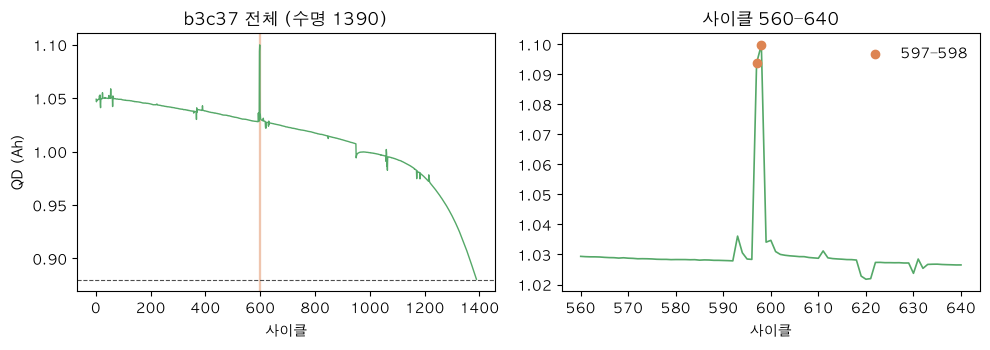

In [8]:
curve = cell_qd("b3c37")
life = int(cells.loc[cells["cell_id"] == "b3c37", "cycle_life"].iloc[0])
window = curve.loc[curve["cycle"].between(590, 610), ["cycle", "QD"]]
print(window.round(4).to_string(index=False))
jump = window["QD"].max() - window.loc[window["cycle"] == 596, "QD"].iloc[0]
print(f"b3c37 life={life}, 596 대비 스파이크 높이 {jump:.4f} Ah")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(curve["cycle"], curve["QD"], color="#55A868", lw=1)
axes[0].axhline(0.88, color="0.3", ls="--", lw=0.8)
axes[0].axvspan(597, 598, color="#DD8452", alpha=0.35)
axes[0].set_title(f"b3c37 전체 (수명 {life})")
axes[0].set_xlabel("사이클")
axes[0].set_ylabel("QD (Ah)")
zoom = curve.loc[curve["cycle"].between(560, 640)]
axes[1].plot(zoom["cycle"], zoom["QD"], color="#55A868", lw=1.2)
spike = curve.loc[curve["cycle"].isin([597, 598])]
axes[1].scatter(spike["cycle"], spike["QD"], color="#DD8452", zorder=3, label="597–598")
axes[1].set_title("사이클 560–640")
axes[1].set_xlabel("사이클")
axes[1].legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "q2_b3c37.png", dpi=150, bbox_inches="tight")
plt.show()


### 목적
b3c37을 데이터에서 뺄지 결정하려고, 사이클 599 근처 용량 점프가 곡선 전체의 수준을 바꾸는지 본다.

### 결과
수명은 1,390이고 마지막에는 0.88Ah 근처까지 내려간다. 사이클 596의 QD는 1.028Ah, 597은 1.094Ah, 598은 1.100Ah, 599는 1.034Ah다. 약 0.066Ah가 두 사이클 동안 올라갔다가 599에서 원래 궤적(약 1.03Ah)으로 돌아온다. 그 뒤 곡선은 다시 완만히 감소한다. 점프는 초기 100사이클 밖에 있다.

### 해석
한 방향으로 용량이 영구히 뛴 측정 오류가 아니라, 두 사이클짜리 스파이크 뒤에 복귀한 흔적이다. 셀의 수명 정의(0.88Ah 도달)와 초기 100사이클 피처는 이 두 점의 영향을 받지 않는다. 전지를 버리는 근거로는 약하다.

### 시사점 → 모델링
**확정: b3c37은 유지한다.** 두 사이클 스파이크이고 초기 100사이클 밖이라 셀을 빼지 않는다. 전체 곡선을 해석할 때만 597–598을 이상 구간으로 표시하면 된다. 초기 100사이클 피처에는 넣지 않아도 되는 구간이다.


## EDA Q3. ΔQ(V)

ΔQ(V) = 사이클 100의 Qdlin − 사이클 10의 Qdlin이다.
Qdlin 행 k는 사이클 k+1이므로 사이클 10은 행 9, 사이클 100은 행 99다.
Vdlin은 세 배치가 같고 3.5V에서 2.0V까지 1000점이다. 2V 근처 값은 인덱스 999다.

summary 피처를 만들기 전에 단발 스파이크를 앞뒤 사이클 중앙값으로 바꾼다.
임계값은 열마다 고정해 두었고, 학습 데이터로 추정하지 않는다.


In [9]:
import pickle

from scipy.stats import pearsonr, spearmanr

from src.config import DATA_PROCESSED_DIR
from src.features import (
    CYCLE_10_ROW,
    CYCLE_100_ROW,
    build_delta_q_table,
    correct_summary_spikes,
    delta_q,
)

# 행 9 = 사이클 10, 행 99 = 사이클 100. 피처 함수와 같은 인덱스.
print(f"사이클 10 = Qdlin 행 {CYCLE_10_ROW}, 사이클 100 = Qdlin 행 {CYCLE_100_ROW}")

frames = []
qdlin = {}
vdlin = None
usable = set(cells["cell_id"])
for batch_id in (1, 2, 3):
    with (DATA_PROCESSED_DIR / f"batch{batch_id}.pkl").open("rb") as handle:
        payload = pickle.load(handle)
    summary = payload["summary"]
    frames.append(summary[summary["cell_id"].isin(usable) & summary["cycle"].between(1, 100)])
    for cell_id, grid in payload["qdlin"].items():
        if cell_id in usable:
            qdlin[cell_id] = grid
    if vdlin is None:
        vdlin = payload["vdlin"]
    del payload

_, spike_log = correct_summary_spikes(pd.concat(frames, ignore_index=True))
print(f"보정 {len(spike_log)}점")
if len(spike_log):
    print(spike_log.groupby(["batch", "column"]).size().unstack(fill_value=0).to_string())
b1c18_qd = spike_log[(spike_log["cell_id"] == "b1c18") & (spike_log["column"] == "QD")]
print(b1c18_qd.round(4).to_string(index=False))

n_bad = 0
n_jump = 0
for grid in qdlin.values():
    for row_index in (CYCLE_10_ROW, CYCLE_100_ROW):
        row = grid[row_index]
        if not np.isfinite(row).all():
            n_bad += 1
            continue
        step = np.abs(np.diff(row))
        if step.max() > max(0.05, 20 * np.median(step)):
            n_jump += 1
print(f"사용 셀 {len(qdlin)}, 사이클 10·100 비유한 행 {n_bad}, 전압축 점프 {n_jump}")
print(f"Vdlin {vdlin[0]:.1f}V → {vdlin[-1]:.1f}V, 2V 인덱스 {int(np.argmin(np.abs(vdlin - 2.0)))}")

curves = {cell_id: delta_q(grid) for cell_id, grid in qdlin.items()}
features = build_delta_q_table(cells, qdlin, vdlin)
features["log_life"] = np.log10(features["cycle_life"])
print(f"ΔQ 피처 {len(features)}행, 결측 {int(features['log10_var'].isna().sum())}")


사이클 10 = Qdlin 행 9, 사이클 100 = Qdlin 행 99


보정 22점
column  IR  QD  Tmin  chargetime
batch                           
1        6   1     0           3
2        0   0     2          10
cell_id  batch  cycle column    old    new
  b1c18      1     40     QD 2.8841 1.0695
사용 셀 119, 사이클 10·100 비유한 행 0, 전압축 점프 0
Vdlin 3.5V → 2.0V, 2V 인덱스 999
ΔQ 피처 119행, 결측 0


### 점검
사이클 10·100의 Qdlin은 사용 셀 119개에서 모두 유한하다. 전압 방향으로 0.05Ah를 넘고 인접 간격 중앙값의 20배를 넘는 점프도 없다. ΔQ를 만들기 전에 Qdlin을 보간하지 않는다.

summary 단발 보정은 22점이다. Batch 1은 10점(IR 6, QD 1, chargetime 3), Batch 2는 12점(Tmin 2, chargetime 10), Batch 3은 0점이다. b1c18 사이클 40 QD는 2.884Ah에서 앞뒤 중앙값 1.069Ah로 바뀐다. QC는 한 점도 바뀌지 않았다. b1c18의 QC는 사이클 36~40에 걸쳐 높아 앞뒤가 서로 멀다.


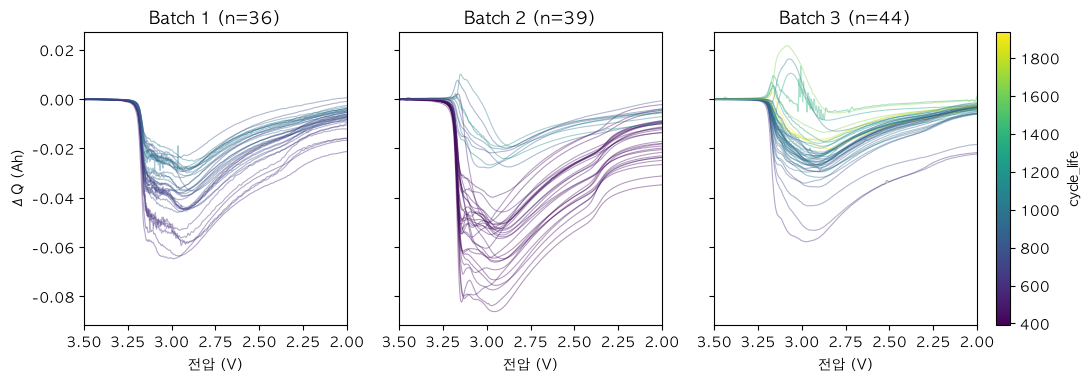

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
norm = plt.Normalize(features["cycle_life"].min(), features["cycle_life"].max())
cmap = plt.cm.viridis
for ax, batch in zip(axes, (1, 2, 3)):
    part = features.loc[features["batch"] == batch]
    for row in part.itertuples(index=False):
        ax.plot(vdlin, curves[row.cell_id], color=cmap(norm(row.cycle_life)), alpha=0.4, lw=0.8)
    ax.set_xlim(3.5, 2.0)
    ax.set_title(f"Batch {batch} (n={len(part)})")
    ax.set_xlabel("전압 (V)")
axes[0].set_ylabel("ΔQ (Ah)")
fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=axes,
    fraction=0.02,
    pad=0.02,
    label="cycle_life",
)
fig.savefig(FIGURES_DIR / "q3_delta_q_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### 목적
사이클 10에서 100 사이 용량-전압 차이가 수명에 따라 갈라지는지, 그 갈라짐이 배치마다 같은 모양인지 본다.

### 결과
곡선은 3.5V에서 거의 0이고, 2.9V 근처에서 가장 음수가 된 뒤 2.0V로 오면서 다시 얕아진다. 색이 수명이라, 골이 깊은 곡선이 짧은 셀이다. 수명 500 미만은 Batch 2에만 28셀이고, 셀별 ΔQ 최솟값의 중앙은 -0.056Ah다. 수명 1,000을 넘는 31셀은 -0.022Ah다.

### 해석
방전 끝 용량(QD 한 점)은 사이클 100에서도 셀들이 비슷했다. 같은 전압에서 읽은 용량은 이미 다르다. 고율 충전으로 잃은 리튬이 전압 곡선을 아래로 누르고, 그 깊이가 남은 수명과 맞닿아 있다.

### 시사점 → 모델링
초기 신호는 QD 평균이 아니라 이 곡선의 깊이다. 요약 통계는 분산과 최솟값을 우선한다. 배치마다 골의 깊이가 그 배치의 수명 분포를 따라가므로, 세 배치 곡선을 한 평균으로 뭉개지 않는다.


Batch 1 장수명: n=9, 수명 876~1074, 최솟값 -0.0288 Ah, 골 전압 2.93 V
Batch 1 단수명: n=9, 수명 534~651, 최솟값 -0.0563 Ah, 골 전압 2.95 V
Batch 2 장수명: n=10, 수명 514~1186, 최솟값 -0.0226 Ah, 골 전압 2.91 V
Batch 2 단수명: n=10, 수명 392~437, 최솟값 -0.0642 Ah, 골 전압 2.98 V
Batch 3 장수명: n=11, 수명 1156~1935, 최솟값 -0.0170 Ah, 골 전압 2.88 V
Batch 3 단수명: n=11, 수명 541~828, 최솟값 -0.0281 Ah, 골 전압 2.98 V


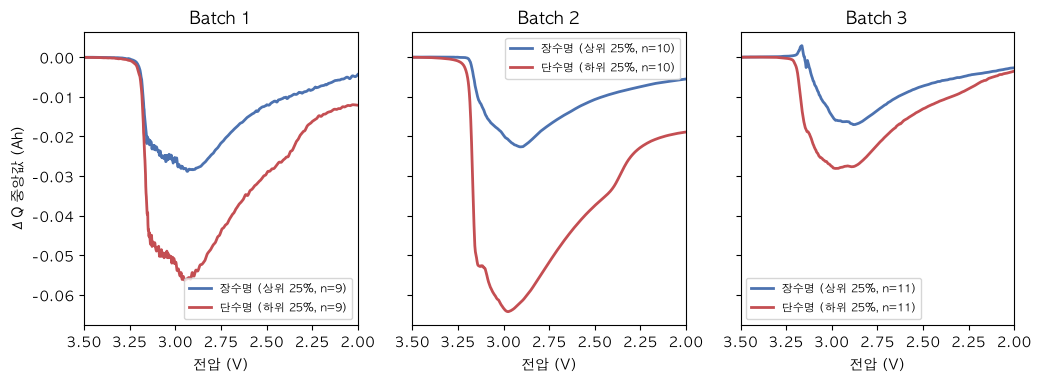

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, batch in zip(axes, (1, 2, 3)):
    part = features.loc[features["batch"] == batch]
    k = int(np.ceil(len(part) * 0.25))
    groups = (
        ("장수명", "상위 25%", part.nlargest(k, "cycle_life"), "#4C72B0"),
        ("단수명", "하위 25%", part.nsmallest(k, "cycle_life"), "#C44E52"),
    )
    for name, band, chosen, color in groups:
        median_curve = np.median(np.vstack([curves[cell_id] for cell_id in chosen["cell_id"]]), axis=0)
        ax.plot(vdlin, median_curve, color=color, lw=2, label=f"{name} ({band}, n={len(chosen)})")
        print(
            f"Batch {batch} {name}: n={len(chosen)}, "
            f"수명 {chosen['cycle_life'].min():.0f}~{chosen['cycle_life'].max():.0f}, "
            f"최솟값 {median_curve.min():.4f} Ah, "
            f"골 전압 {vdlin[int(np.argmin(median_curve))]:.2f} V"
        )
    ax.set_xlim(3.5, 2.0)
    ax.set_title(f"Batch {batch}")
    ax.set_xlabel("전압 (V)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("ΔQ 중앙값 (Ah)")
fig.savefig(FIGURES_DIR / "q3_long_short.png", dpi=150, bbox_inches="tight")
plt.show()


### 목적
각 배치 안에서 수명 상위 25%와 하위 25%의 ΔQ가 깊이만 다른지, 골의 위치까지 다른지 본다.

### 결과
세 배치 모두 두 중앙 곡선이 있다. 단수명 최솟값은 Batch 1 -0.0563Ah(n=9), Batch 2 -0.0642Ah(n=10), Batch 3 -0.0281Ah(n=11)다. 장수명 최솟값은 Batch 1 -0.0288Ah(n=9), Batch 2 -0.0226Ah(n=10), Batch 3 -0.0170Ah(n=11)다. Batch 1에서도 단수명 골이 장수명보다 깊다. 골 전압은 2.88~2.98V다.

### 해석
수명은 새 피크가 생겨서가 아니라, 같은 전압 창에서 용량이 더 많이 빠지면서 갈린다. 단수명 골은 장수명보다 Batch 1에서 약 2배, Batch 2에서 약 3배, Batch 3에서 약 1.7배 깊다.

### 시사점 → 모델링
min, var, 2V 값은 같은 깊이를 다른 방식으로 잰다. 비대칭을 재는 skew는 수명과 약할 가능성이 크다. 다음 상관계수에서 걸러낸다.


      feature  pearson  spearman
    log10_var   -0.897    -0.888
       dq_min    0.882     0.876
log10_abs_min   -0.876    -0.876
      dq_mean    0.852     0.861
       dq_var   -0.829    -0.888
     dq_at_2v    0.696     0.704
  dq_kurtosis    0.333     0.404
      dq_skew   -0.028    -0.284
log10(var)와 log10(|min|) 상관 0.965
Batch 1: Pearson -0.844, Spearman -0.826, R² 0.712
Batch 2: Pearson -0.918, Spearman -0.709, R² 0.843
Batch 3: Pearson -0.762, Spearman -0.797, R² 0.581
Batch 2 일반 n=30: Pearson -0.375, 수명 392~514
Batch 2 newstructure n=9: Pearson -0.266, 수명 777~1186


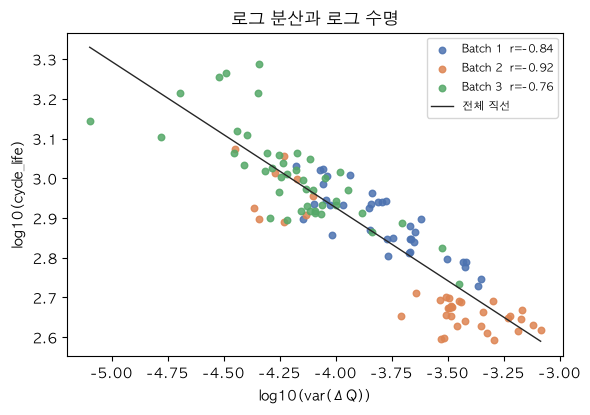

In [12]:
feature_cols = [
    "log10_var",
    "dq_min",
    "log10_abs_min",
    "dq_mean",
    "dq_var",
    "dq_at_2v",
    "dq_kurtosis",
    "dq_skew",
]
corr_rows = []
for column in feature_cols:
    corr_rows.append(
        {
            "feature": column,
            "pearson": pearsonr(features[column], features["log_life"]).statistic,
            "spearman": spearmanr(features[column], features["log_life"]).statistic,
        }
    )
corr = pd.DataFrame(corr_rows)
print(corr.round(3).to_string(index=False))
print(f"log10(var)와 log10(|min|) 상관 {features['log10_var'].corr(features['log10_abs_min']):.3f}")

for batch, part in features.groupby("batch"):
    x = part["log10_var"].to_numpy()
    y = part["log_life"].to_numpy()
    slope, intercept = np.polyfit(x, y, 1)
    fitted = slope * x + intercept
    r2 = 1 - np.sum((y - fitted) ** 2) / np.sum((y - y.mean()) ** 2)
    print(
        f"Batch {batch}: Pearson {pearsonr(x, y).statistic:+.3f}, "
        f"Spearman {spearmanr(x, y).statistic:+.3f}, R² {r2:.3f}"
    )

batch2 = features.loc[features["batch"] == 2]
for name, part in (("일반", batch2.loc[~batch2["newstructure"]]), ("newstructure", batch2.loc[batch2["newstructure"]])):
    print(
        f"Batch 2 {name} n={len(part)}: "
        f"Pearson {pearsonr(part['log10_var'], part['log_life']).statistic:+.3f}, "
        f"수명 {part['cycle_life'].min():.0f}~{part['cycle_life'].max():.0f}"
    )

fig, ax = plt.subplots(figsize=(6.4, 4.2))
for batch, color in COLORS.items():
    part = features.loc[features["batch"] == batch]
    r_value = part["log10_var"].corr(part["log_life"])
    ax.scatter(
        part["log10_var"],
        part["log_life"],
        s=22,
        color=color,
        alpha=0.85,
        label=f"Batch {batch}  r={r_value:.2f}",
    )
slope, intercept = np.polyfit(features["log10_var"], features["log_life"], 1)
grid = np.linspace(features["log10_var"].min(), features["log10_var"].max(), 40)
ax.plot(grid, slope * grid + intercept, color="0.15", lw=1, label="전체 직선")
ax.set_xlabel("log10(var(ΔQ))")
ax.set_ylabel("log10(cycle_life)")
ax.set_title("로그 분산과 로그 수명")
ax.legend(fontsize=8)
fig.savefig(FIGURES_DIR / "q3_logvar_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


### 목적
ΔQ 요약 중 log10(수명)과 직선에 가까운 것을 고르고, 로그 타깃이 이 피처와 맞는지 확인한다.

### 결과
전체 119셀에서 log10(수명)과의 상관은 log10(var)이 Pearson -0.897, Spearman -0.888로 가장 강하다. 다음은 dq_min +0.882, log10(|min|) -0.876, dq_mean +0.852다. 원시 var는 Spearman -0.888, Pearson -0.829라 로그를 취한 쪽이 직선에 가깝다. 2V 값은 +0.696, kurtosis는 +0.333, skew는 -0.028이다. log10(var)와 log10(|min|)의 상관은 0.965다.

배치별 log10(var) 대 log10(수명)은 Batch 1이 Pearson -0.844, Spearman -0.826, R² 0.712다. Batch 3은 -0.762, -0.797, R² 0.581이다. Batch 2는 Pearson -0.918, R² 0.843이지만 Spearman은 -0.709다. Batch 2 일반 셀 30개(수명 392~514)만 보면 Pearson -0.375이고, newstructure 9셀은 -0.266이다.

### 해석
용량 감소 폭이 클수록 수명이 짧다. 학습에 쓰는 Batch 1에서는 Pearson과 Spearman이 거의 같아, 로그 분산과 로그 수명을 직선으로 둬도 된다. 원시 분산은 직선보다 순위 상관이 커서 로그가 필요하다. Batch 2의 높은 Pearson은 수명 400대 덩어리와 800대 이상 덩어리가 떨어져 생긴 값이다. 일반 셀 30개의 Pearson -0.375는 관계가 사라졌다는 뜻이 아니다. 그 셀들의 수명은 392~514, 폭 122사이클뿐이라 수명 분산이 잘려 상관이 작아지는 범위 제한 효과다.

### 시사점 → 모델링
로그 타깃을 유지한다. 핵심 피처는 log10(var(ΔQ))로 둔다. log10(|min ΔQ|)는 상관 0.965라 둘 중 하나만 쓰고, 어느 쪽인지는 Q5에서 정한다. skew는 제외한다. 배치 번호는 피처로 쓰지 않는다.


수명 700–1,100 log10(var) 중앙
       count  median
batch               
1         26  -3.851
2          7  -4.231
3         28  -4.122
Batch 1 수명 700–1,100 n=26, 3.0V ΔQ -0.0312 Ah
Batch 2 수명 700–1,100 n=7, 3.0V ΔQ -0.0209 Ah
Batch 3 수명 700–1,100 n=28, 3.0V ΔQ -0.0241 Ah


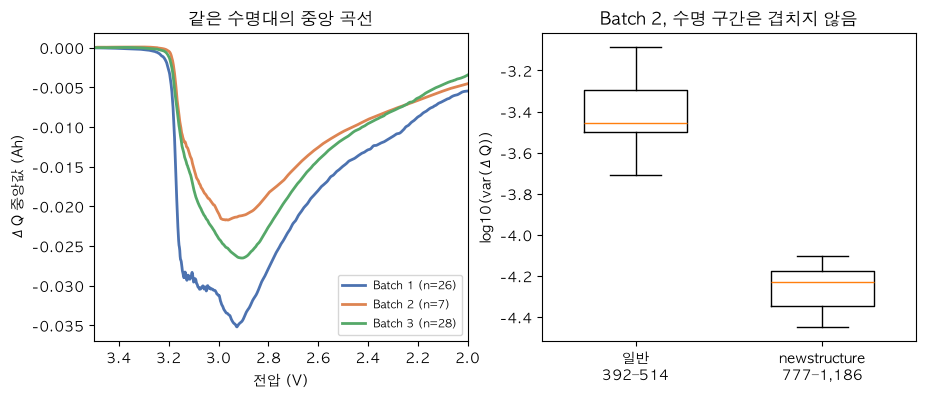

newstructure 셀 수 {(1, False): 36, (2, False): 30, (2, True): 9, (3, True): 44}


In [13]:
band = features.loc[features["cycle_life"].between(700, 1100)]
print("수명 700–1,100 log10(var) 중앙")
print(band.groupby("batch")["log10_var"].agg(["count", "median"]).round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.0))
for batch, color in COLORS.items():
    chosen = band.loc[band["batch"] == batch, "cell_id"]
    median_curve = np.median(np.vstack([curves[cell_id] for cell_id in chosen]), axis=0)
    voltage_index = int(np.argmin(np.abs(vdlin - 3.0)))
    print(f"Batch {batch} 수명 700–1,100 n={len(chosen)}, 3.0V ΔQ {median_curve[voltage_index]:.4f} Ah")
    axes[0].plot(vdlin, median_curve, color=color, lw=2, label=f"Batch {batch} (n={len(chosen)})")
axes[0].set_xlim(3.5, 2.0)
axes[0].set_xlabel("전압 (V)")
axes[0].set_ylabel("ΔQ 중앙값 (Ah)")
axes[0].set_title("같은 수명대의 중앙 곡선")
axes[0].legend(fontsize=8)

batch2 = features.loc[features["batch"] == 2]
box_data = [
    batch2.loc[~batch2["newstructure"], "log10_var"],
    batch2.loc[batch2["newstructure"], "log10_var"],
]
axes[1].boxplot(box_data, tick_labels=["일반\n392–514", "newstructure\n777–1,186"], widths=0.55)
axes[1].set_ylabel("log10(var(ΔQ))")
axes[1].set_title("Batch 2, 수명 구간은 겹치지 않음")
fig.savefig(FIGURES_DIR / "q3_batch_distortion.png", dpi=150, bbox_inches="tight")
plt.show()
print("newstructure 셀 수", features.groupby(["batch", "newstructure"]).size().to_dict())


### 목적
배치마다 충전 곡선 시작이 달라 Qdlin 비교가 왜곡되는지, 그 왜곡이 newstructure 이름 때문인지 가른다.

### 결과
newstructure는 Batch 1이 0셀, Batch 2가 9셀, Batch 3가 44셀 전부다. Batch 2에서 newstructure 수명은 777~1,186이고 일반 셀은 392~514라 겹치지 않는다. 그래서 오른쪽 그림의 log10(var) 차이(중앙 -4.23 대 -3.46)는 수명 차이와 분리되지 않는다.

수명을 700~1,100으로 맞추면 log10(var) 중앙은 Batch 1 -3.851(26셀), Batch 2 -4.231(7셀, 전부 newstructure), Batch 3 -4.122(28셀)다. 3.0V 중앙 ΔQ는 Batch 1 -0.0312Ah, Batch 2 -0.0209Ah, Batch 3 -0.0241Ah다. 골의 전압은 2.90~2.93V로 같다. 같은 수명인데 Batch 1의 감소 폭이 더 크다.

### 해석
newstructure라는 이름이 곡선 모양을 새로 만드는 것은 아니다. Batch 2 안의 형태 차이는 짧은 셀과 긴 셀의 차이다. 수명을 맞추면 갈라지는 쪽은 Batch 1과 그 뒤 배치다. 뒤 배치는 같은 수명에서도 ΔQ가 얕아, 열화가 덜 진행된 셀처럼 보인다. 충전 곡선이 잡히기 시작한 시점이 배치마다 달라 같은 전압 인덱스에 다른 구간이 들어온 영향과 맞다.

### 시사점 → 모델링
같은 수명대에서 Batch 1의 ΔQ 골이 더 깊다. Batch 1로 학습한 모델은 ΔQ가 얕은 Batch 2·3 셀을 열화가 덜 된 셀로 읽고, 수명을 과대예측할 수 있다. 이 스케일 차이가 DAY 2 Gap(Valid-Test)의 예상 원인이다. Gap(Valid-Test) = Test MAPE − Valid MAPE 이므로, 테스트만 나빠지면 이 값이 양수가 된다. 배치 번호는 피처로 넣지 않는다. 학습은 Batch 1뿐이라 배치 효과가 추정되지 않는다.


## EDA Q4. 충전 조건(C-rate)

`policy_readable`은 `C1C(전환 SOC%)-C2C`이고, Batch 2·3 일부는 뒤에 `-newstructure`가 붙는다.
평균 C-rate는 용량 가중 산술평균이 아니다. s = SOC/100일 때 1 / (s/C1 + (1−s)/C2)로, 같은 용량을 두 단계로 채우는 등가 속도다.
초기 chargetime은 실제 충전 5회의 평균이다. Batch 1 사이클 1은 chargetime이 0인 빈 사이클이라 빼고, 그다음 5회를 쓴다.


In [14]:
import pickle

from src.config import DATA_PROCESSED_DIR
from src.features import (
    correct_summary_spikes,
    early_chargetime_mean,
    parse_policies,
    qd_window_slope,
)

policy = cells.copy()
parsed = parse_policies(policy["policy_readable"])
n_fail = int((~parsed["policy_ok"]).sum())
print(f"파싱 실패 {n_fail} / {len(policy)}")
if n_fail:
    print(policy.loc[~parsed["policy_ok"].to_numpy(), "policy_readable"].unique())
policy = pd.concat([policy.reset_index(drop=True), parsed.reset_index(drop=True)], axis=1)
policy["log_life"] = np.log10(policy["cycle_life"])

frames = []
usable = set(policy["cell_id"])
for batch_id in (1, 2, 3):
    with (DATA_PROCESSED_DIR / f"batch{batch_id}.pkl").open("rb") as handle:
        summary = pickle.load(handle)["summary"]
    frames.append(summary[summary["cell_id"].isin(usable) & summary["cycle"].between(1, 100)])
corrected, _ = correct_summary_spikes(pd.concat(frames, ignore_index=True))
policy["early_ct"] = policy["cell_id"].map(early_chargetime_mean(corrected))
policy["qd_slope"] = policy["cell_id"].map(qd_window_slope(corrected))
print(f"chargetime 결측 {int(policy['early_ct'].isna().sum())}, 기울기 결측 {int(policy['qd_slope'].isna().sum())}")

batch1 = policy.loc[policy["batch"] == 1]
base_in_train = set(batch1["policy_base"])
print(
    f"Batch 1 범위  C1 {batch1['c1'].min():.1f}~{batch1['c1'].max():.1f}, "
    f"SOC {batch1['soc_pct'].min():.0f}~{batch1['soc_pct'].max():.0f}%, "
    f"C2 {batch1['c2'].min():.1f}~{batch1['c2'].max():.1f}"
)
for batch_id in (2, 3):
    part = policy.loc[policy["batch"] == batch_id]
    unseen_string = ~part["policy_readable"].isin(set(batch1["policy_readable"]))
    unseen_base = ~part["policy_base"].isin(base_in_train)
    outside = (
        (part["c1"] < batch1["c1"].min())
        | (part["c1"] > batch1["c1"].max())
        | (part["c2"] < batch1["c2"].min())
        | (part["c2"] > batch1["c2"].max())
        | (part["soc_pct"] < batch1["soc_pct"].min())
        | (part["soc_pct"] > batch1["soc_pct"].max())
    )
    print(
        f"Batch {batch_id}: 문자열 미학습 {int(unseen_string.sum())}/{len(part)}셀 "
        f"({part.loc[unseen_string, 'policy_readable'].nunique()}종), "
        f"전류식 미학습 {int(unseen_base.sum())}/{len(part)}셀 "
        f"({part.loc[unseen_base, 'policy_base'].nunique()}종), "
        f"숫자 범위 밖 {int(outside.sum())}셀"
    )
    print("  범위 밖:", sorted(part.loc[outside, "policy_base"].unique()))


파싱 실패 0 / 119


chargetime 결측 0, 기울기 결측 0
Batch 1 범위  C1 4.4~8.0, SOC 15~80%, C2 3.0~5.4
Batch 2: 문자열 미학습 32/39셀 (10종), 전류식 미학습 29/39셀 (7종), 숫자 범위 밖 6셀
  범위 밖: ['3.6C(30%)-6C', '3.6C(9%)-5C', '4.65C(69%)-6C']
Batch 3: 문자열 미학습 44/44셀 (8종), 전류식 미학습 38/44셀 (7종), 숫자 범위 밖 3셀
  범위 밖: ['3.7C(31%)-5.9C']


### 점검
119셀 모두 `C1C(SOC%)-C2C` 또는 그 뒤에 `-newstructure`가 붙은 형식으로 파싱된다. 실패는 0건이다.

Batch 1이 본 범위는 C1 4.4~8.0, 전환 SOC 15~80%, C2 3.0~5.4다. Batch 2는 정책 문자열 기준 32/39셀(10/12종), 접미사를 뺀 전류식 기준 29/39셀(7/9종)이 여기에 없다. 숫자 범위 밖은 6셀이고 정책은 `3.6C(30%)-6C`, `3.6C(9%)-5C`, `4.65C(69%)-6C`다. Batch 3는 문자열 44/44셀, 전류식 38/44셀이 새 조합이다. 범위 밖은 `3.7C(31%)-5.9C` 3셀뿐이다. 전류 숫자 자체는 대부분 Batch 1 상자 안이고, 없는 것은 그 조합과 newstructure 접미사다.


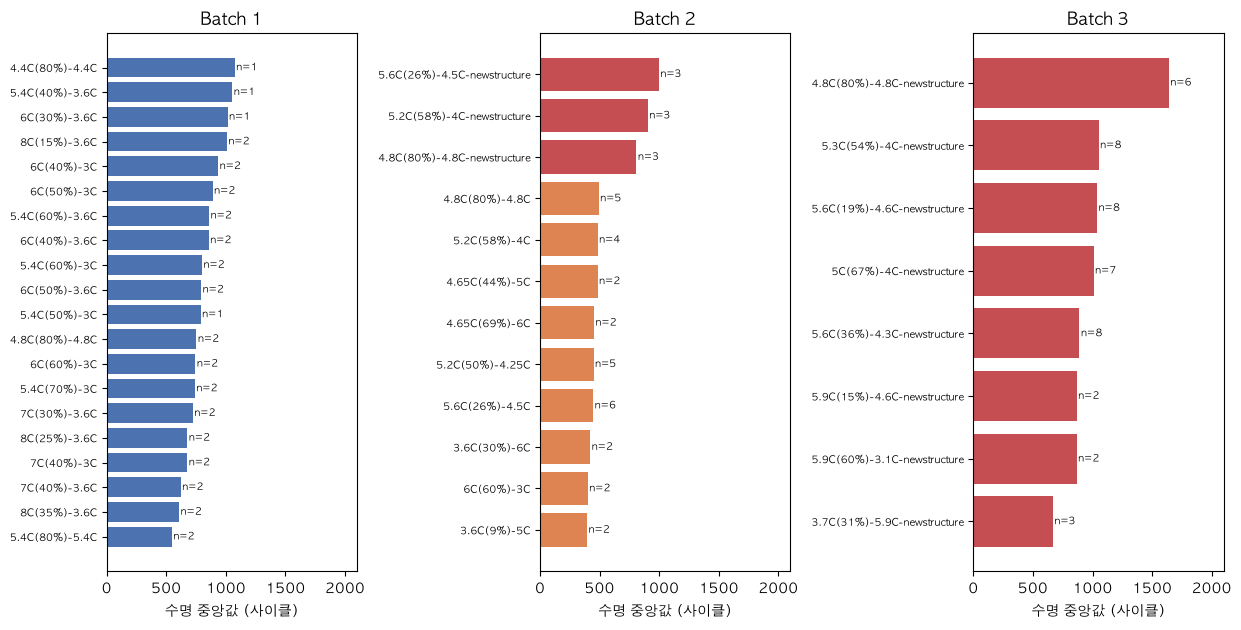

                    count  median
batch newstructure               
1     False             2   753.0
2     False             5   492.0
      True              3   809.0
3     True              6  1640.0


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 6.4))
for ax, batch_id in zip(axes, (1, 2, 3)):
    part = policy.loc[policy["batch"] == batch_id]
    table = (
        part.groupby("policy_readable")["cycle_life"]
        .agg(median="median", n="count")
        .sort_values("median")
    )
    colors = ["#C44E52" if "newstructure" in name else COLORS[batch_id] for name in table.index]
    ax.barh(np.arange(len(table)), table["median"], color=colors)
    ax.set_yticks(np.arange(len(table)))
    ax.set_yticklabels(table.index, fontsize=7)
    for y_pos, (median_life, n_cells) in enumerate(zip(table["median"], table["n"])):
        ax.text(median_life + 15, y_pos, f"n={int(n_cells)}", va="center", fontsize=7)
    ax.set_xlim(0, 2100)
    ax.set_xlabel("수명 중앙값 (사이클)")
    ax.set_title(f"Batch {batch_id}")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "q4_policy_life.png", dpi=150, bbox_inches="tight")
plt.show()

focus = policy.loc[policy["policy_base"] == "4.8C(80%)-4.8C"]
print(
    focus.groupby(["batch", "newstructure"])["cycle_life"]
    .agg(["count", "median"])
    .round(0)
    .to_string()
)


### 목적
같은 충전 정책의 수명이 배치를 넘어 유지되는지, 고율을 오래 유지하는 정책이 짧은지 본다.

### 결과
Batch 1에서 n≥2로 가장 짧은 정책은 5.4C(80%)-5.4C, 중앙 546사이클(n=2)이다. 가장 긴 쪽은 n=1이라 경향만 본다. 4.4C(80%)-4.4C가 1,074, 5.4C(40%)-3.6C가 1,054다. 8C라도 15%에서 내리면 중앙 1,008(n=2)이고, 35%까지 8C를 유지하면 608이다.

Batch 2 일반 셀은 정책 중앙값이 394~492에 몰린다. 같은 전류식의 newstructure만 길다. 4.8C(80%)-4.8C는 일반 492(n=5), newstructure 809(n=3)다. 5.2C(58%)-4C는 483 대 904, 5.6C(26%)-4.5C는 446 대 997이다.

같은 4.8C(80%)-4.8C의 중앙 수명은 Batch 1이 753(n=2), Batch 3 newstructure가 1,640(n=6)이다. 6C(60%)-3C는 Batch 1 중앙 744, Batch 2 중앙 400이다.

### 해석
수명을 가르는 것은 피크 전류 하나보다, 고율을 어느 SOC까지 유지하는가다. 다만 그 문자는 배치를 넘어 같은 수명을 뜻하지 않는다. newstructure가 붙으면 Batch 2 안에서 수명이 약 두 배가 되고, Batch 3의 같은 식은 거기서 다시 길어진다. 셀 내부 구조나 충전 곡선이 잡히는 시점이 배치마다 달라, 전류 숫자만으로 수명이 고정되지 않는다.

### 시사점 → 모델링
정책별 평균은 n이 1~2인 곳이 많아 그 순위를 계수로 외우면 안 된다. 같은 전류식의 수명이 배치마다 다르므로, 정책 문자열을 범주 피처로 두면 테스트 범주가 학습에 없다.


C1 Batch 1: Pearson(log 수명) -0.238
C1 Batch 2: Pearson(log 수명) +0.196
C1 Batch 3: Pearson(log 수명) +0.018
C2 Batch 1: Pearson(log 수명) -0.292
C2 Batch 2: Pearson(log 수명) -0.110
C2 Batch 3: Pearson(log 수명) -0.125
평균 C-rate Batch 1: Pearson(log 수명) -0.532
평균 C-rate Batch 2: Pearson(log 수명) -0.038
평균 C-rate Batch 3: Pearson(log 수명) -0.054
전환 SOC Batch 1: Pearson(log 수명) -0.181
전환 SOC Batch 2: Pearson(log 수명) +0.164
전환 SOC Batch 3: Pearson(log 수명) +0.520


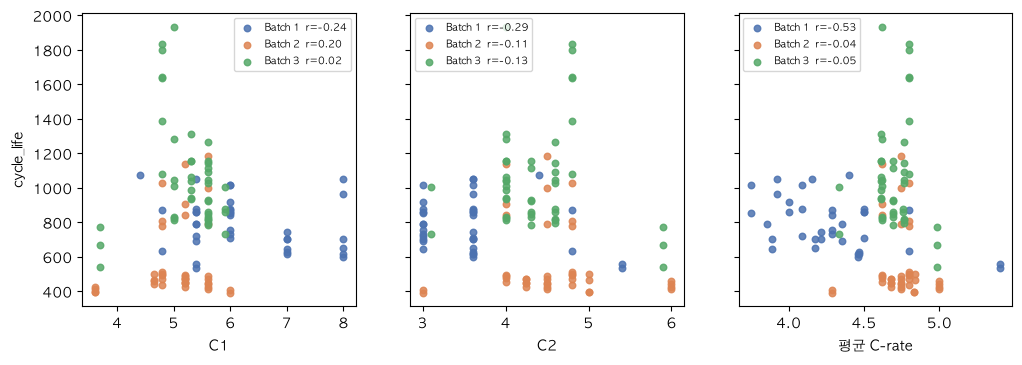

In [16]:
from scipy.stats import pearsonr

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, column, label in zip(axes, ("c1", "c2", "c_avg"), ("C1", "C2", "평균 C-rate")):
    for batch_id, color in COLORS.items():
        part = policy.loc[policy["batch"] == batch_id]
        r_value = pearsonr(part[column], part["log_life"]).statistic
        ax.scatter(part[column], part["cycle_life"], s=22, color=color, alpha=0.85, label=f"Batch {batch_id}  r={r_value:.2f}")
        print(f"{label} Batch {batch_id}: Pearson(log 수명) {r_value:+.3f}")
    ax.set_xlabel(label)
    ax.legend(fontsize=7)
axes[0].set_ylabel("cycle_life")
for batch_id in (1, 2, 3):
    part = policy.loc[policy["batch"] == batch_id]
    r_value = pearsonr(part["soc_pct"], part["log_life"]).statistic
    print(f"전환 SOC Batch {batch_id}: Pearson(log 수명) {r_value:+.3f}")
fig.savefig(FIGURES_DIR / "q4_crate_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


### 목적
C1, C2, 평균 C-rate가 로그 수명과 얼마나 직선인지, 그 관계가 배치마다 같은지 본다. 그림의 r은 log10(cycle_life)와의 Pearson이다.

### 결과
Batch 1에서 Pearson은 평균 C-rate -0.532, C2 -0.292, C1 -0.238, 전환 SOC -0.181이다. 평균 속도가 높을수록 수명이 짧다. Batch 2의 평균 C-rate는 -0.038, Batch 3는 -0.054다. C1도 Batch 2 +0.196, Batch 3 +0.018로 Batch 1의 부호가 유지되지 않는다. 전환 SOC는 Batch 3에서 +0.520이지만, 가장 긴 정책이 SOC 80%인 4.8C(80%)-4.8C(중앙 1,640)라 한 정책이 끌어올린 값이다. Batch 1의 SOC 상관은 -0.181로 부호가 반대다.

### 해석
학습 배치 안에서는 두 단계 충전을 하나의 등가 속도로 묶은 값이 피크 전류보다 수명과 가깝다. 고율 구간이 짧으면 평균 속도가 내려가고 수명이 길어진다. 테스트 배치에서는 이 기울기가 없다. 수명 차이가 전류 숫자 밖(newstructure, 배치별 충전 곡선)에 있기 때문이다.

### 시사점 → 모델링
평균 C-rate를 넣더라도 Batch 1 상관 -0.53은 log10(var(ΔQ)) -0.84보다 약하다. Batch 2·3에서 상관이 0 근처라, 학습에서 얻은 기울기를 테스트에 적용하면 수명을 거의 움직이지 않거나 엉뚱한 방향으로 민다.


Batch 1: c_avg–chargetime -0.902, chargetime–log수명 +0.575, c_avg–QD기울기 -0.666
Batch 2: c_avg–chargetime +0.144, chargetime–log수명 -0.937, c_avg–QD기울기 -0.290
Batch 3: c_avg–chargetime +0.323, chargetime–log수명 +0.600, c_avg–QD기울기 -0.584


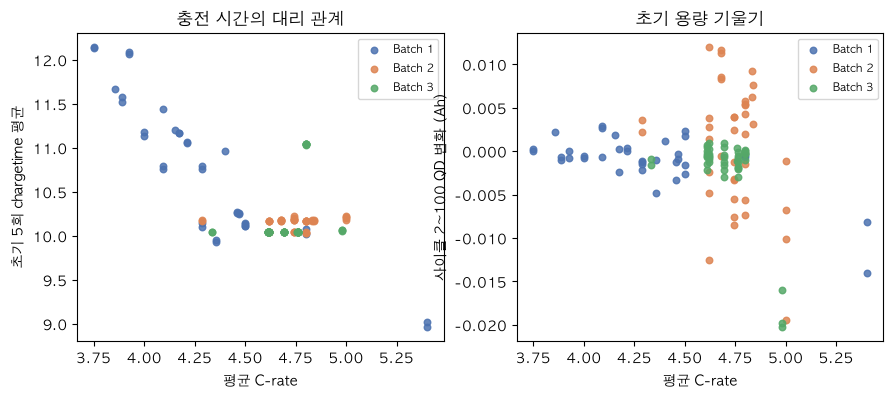

Batch 2 일반: chargetime 중앙 10.175, 범위 0.055, log수명 상관 -0.192
Batch 2 newstructure: chargetime 중앙 10.040, 범위 0.005, log수명 상관 -0.124
Batch 1 기울기×100사이클 중앙 -0.0007 Ah


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.0))
for batch_id, color in COLORS.items():
    part = policy.loc[policy["batch"] == batch_id]
    axes[0].scatter(part["c_avg"], part["early_ct"], s=22, color=color, alpha=0.85, label=f"Batch {batch_id}")
    axes[1].scatter(part["c_avg"], part["qd_slope"] * 100, s=22, color=color, alpha=0.85, label=f"Batch {batch_id}")
    print(
        f"Batch {batch_id}: c_avg–chargetime {pearsonr(part['c_avg'], part['early_ct']).statistic:+.3f}, "
        f"chargetime–log수명 {pearsonr(part['early_ct'], part['log_life']).statistic:+.3f}, "
        f"c_avg–QD기울기 {pearsonr(part['c_avg'], part['qd_slope']).statistic:+.3f}"
    )
axes[0].set_xlabel("평균 C-rate")
axes[0].set_ylabel("초기 5회 chargetime 평균")
axes[0].set_title("충전 시간의 대리 관계")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("평균 C-rate")
axes[1].set_ylabel("사이클 2~100 QD 변화 (Ah)")
axes[1].set_title("초기 용량 기울기")
axes[1].legend(fontsize=8)
fig.savefig(FIGURES_DIR / "q4_chargetime_slope.png", dpi=150, bbox_inches="tight")
plt.show()

batch2 = policy.loc[policy["batch"] == 2]
for name, part in (("일반", batch2.loc[~batch2["newstructure"]]), ("newstructure", batch2.loc[batch2["newstructure"]])):
    print(
        f"Batch 2 {name}: chargetime 중앙 {part['early_ct'].median():.3f}, "
        f"범위 {part['early_ct'].max() - part['early_ct'].min():.3f}, "
        f"log수명 상관 {pearsonr(part['early_ct'], part['log_life']).statistic:+.3f}"
    )
print(
    "Batch 1 기울기×100사이클 중앙 "
    f"{(batch1['qd_slope'] * 100).median():.4f} Ah"
)


### 목적
초기 5회 chargetime이 평균 C-rate의 대리 변수인지, 평균 C-rate가 초기 100사이클 용량 기울기로 이어지는지 본다.

### 결과
Batch 1에서 평균 C-rate와 chargetime의 Pearson은 -0.902다. 등가 속도가 높으면 초기 충전이 짧고, chargetime과 log 수명의 상관은 +0.575다. Batch 2에서는 평균 C-rate와 chargetime이 +0.144로 대리가 깨진다. chargetime과 log 수명 -0.937은 일반 셀 중앙 10.175와 newstructure 중앙 10.040의 차이다. 일반 셀 안(범위 0.055)에서는 -0.192, newstructure 안에서는 -0.124다. Batch 3 chargetime은 대부분 10.04 근처에 있고, 4.8C(80%)-4.8C 셀만 약 11이다.

사이클 2~100 QD 기울기에 100을 곱하면 Batch 1 중앙 변화는 -0.0007Ah다. 평균 C-rate와 기울기의 상관은 Batch 1에서 -0.666이지만, 쌓이는 용량 차이는 0.01Ah를 넘지 않는다.

### 해석
Batch 1 안에서는 충전 시간이 평균 속도를 잘 따라간다. 테스트 배치에서는 충전 시각을 재는 기준이 달라, 0.1 정도의 chargetime 차이가 수명 두 배와 한 축에 놓인다. 초기 용량 기울기는 전류와 같은 방향이어도 크기가 열화라고 부르기 어렵다. 고율의 손상은 이 100사이클의 방전 끝 용량에 아직 쌓이지 않는다.

### 시사점 → 모델링
chargetime을 C-rate 대신 넣어도 테스트에서는 대리 관계가 없다. 초기 QD 기울기도 수명 피처로 기대하지 않는다. 초기 신호는 Q3의 ΔQ(V) 쪽에 있다.


전류식이 Batch 1에 있음 / 없음: [(1, 36, 0), (2, 10, 29), (3, 6, 38)]


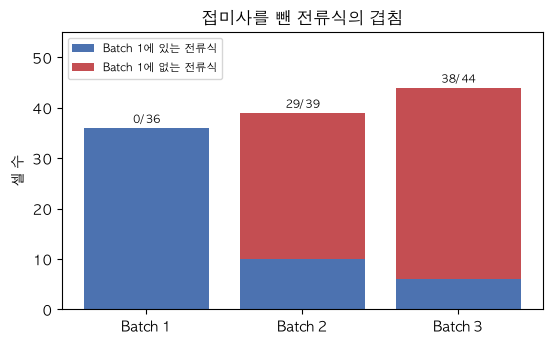

In [18]:
counts = []
for batch_id in (1, 2, 3):
    part = policy.loc[policy["batch"] == batch_id]
    known = part["policy_base"].isin(base_in_train).sum()
    counts.append((batch_id, int(known), int(len(part) - known)))
print("전류식이 Batch 1에 있음 / 없음:", counts)

fig, ax = plt.subplots(figsize=(6.2, 3.6))
x = np.arange(3)
known_n = [item[1] for item in counts]
unknown_n = [item[2] for item in counts]
ax.bar(x, known_n, color="#4C72B0", label="Batch 1에 있는 전류식")
ax.bar(x, unknown_n, bottom=known_n, color="#C44E52", label="Batch 1에 없는 전류식")
for pos, (known, unknown) in enumerate(zip(known_n, unknown_n)):
    ax.text(pos, known + unknown + 1, f"{unknown}/{known + unknown}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(["Batch 1", "Batch 2", "Batch 3"])
ax.set_ylabel("셀 수")
ax.set_ylim(0, 55)
ax.set_title("접미사를 뺀 전류식의 겹침")
ax.legend(fontsize=8)
fig.savefig(FIGURES_DIR / "q4_policy_coverage.png", dpi=150, bbox_inches="tight")
plt.show()


### 목적
테스트 배치의 정책이 학습 배치에 없는지 세어, 정책 피처가 일반화되는지 판단한다.

### 결과
접미사를 뺀 전류식이 Batch 1에 없는 셀은 Batch 2가 29/39, Batch 3가 38/44다. 정책 문자열 그대로는 Batch 2가 32/39, Batch 3가 44/44다. 숫자 범위 밖은 각각 6셀, 3셀이라, 못 본 C-rate 끝값보다 못 본 조합이 더 많다. 겹치는 4.8C(80%)-4.8C도 중앙 수명이 753, 492, 809, 1,640으로 배치와 접미사에 따라 갈린다.

### 해석
같은 배치 안에서는 고속 충전이 수명을 줄인다. Batch 1에서 평균 C-rate와 log 수명의 Pearson은 -0.53이다. 배치가 바뀌면 그 관계는 사라진다. Batch 2는 -0.04, Batch 3는 -0.05다. 같은 4.8C(80%)-4.8C도 중앙 수명이 492에서 1,640까지 갈린다. 전류 숫자는 충전 조건이지, 셀 안에 쌓인 열화의 결과가 아니다.

### 시사점 → 모델링
**확정:** C1, 전환 SOC, C2, 평균 C-rate, 초기 chargetime은 메인 모델에 넣지 않는다. 근거는 네 가지다. Batch 1에서도 log10(var(ΔQ))보다 약하다. 테스트 배치에서 수명과 상관이 없다. 같은 정책의 중앙 수명이 배치에 따라 492~1,640으로 달라진다. Batch 2의 29/39, Batch 3의 38/44가 학습에 없던 전류식이다. 그래서 메인 피처는 충전 조건이 아니라, 배터리 내부 상태의 결과인 ΔQ(V)다. 정책 피처는 아래 순위표에 비교용으로만 남긴다.


### 프로토콜별 평균 수명

Batch 1에서 정책별 평균 수명이 긴 쪽과 짧은 쪽을 본다. n이 1~2라 순위는 경향이다.


In [19]:
batch1_policy = (
    policy.loc[policy["batch"] == 1]
    .groupby("policy_readable")["cycle_life"]
    .agg(n="count", mean="mean")
    .sort_values("mean")
)
print("하위 5")
print(batch1_policy.head(5).round(1).to_string())
print("상위 5")
print(batch1_policy.tail(5).round(1).to_string())


하위 5
                 n   mean
policy_readable          
5.4C(80%)-5.4C   2  546.5
8C(35%)-3.6C     2  607.5
7C(40%)-3.6C     2  621.0
7C(40%)-3C       2  676.0
8C(25%)-3.6C     2  676.5
상위 5
                 n    mean
policy_readable           
6C(40%)-3C       2   935.5
8C(15%)-3.6C     2  1008.5
6C(30%)-3.6C     1  1014.0
5.4C(40%)-3.6C   1  1054.0
4.4C(80%)-4.4C   1  1074.0


### 목적
고율을 오래 유지하는 정책이 Batch 1에서 실제로 짧은지, 셀 수가 순위를 받치는지 본다.

### 결과
하위 5개의 평균 수명은 546.5~676.5사이클이고 모두 n=2다. 가장 짧은 정책은 5.4C(80%)-5.4C(546.5)다. 상위 5개는 935.5~1,074다. 그중 6C(30%)-3.6C, 5.4C(40%)-3.6C, 4.4C(80%)-4.4C는 n=1이라 경향만 본다. 8C라도 15%에서 내리면 평균 1,008.5(n=2)이고, 35%까지 유지하면 607.5다.

### 해석
피크 전류보다 고율을 높은 SOC까지 유지하는 정책이 짧다. 표본이 정책당 1~2셀이라 이 순위를 계수로 쓰지 않는다.

### 시사점 → 모델링
정책 평균 수명은 메인 피처가 아니다. 같은 전류식의 수명이 배치마다 다르다는 앞의 결론을 배치 1 안에서 다시 보여 줄 뿐이다.


기울기 결측 0
Batch 1: Pearson -0.739
Batch 2: Pearson -0.315
Batch 3: Pearson -0.586


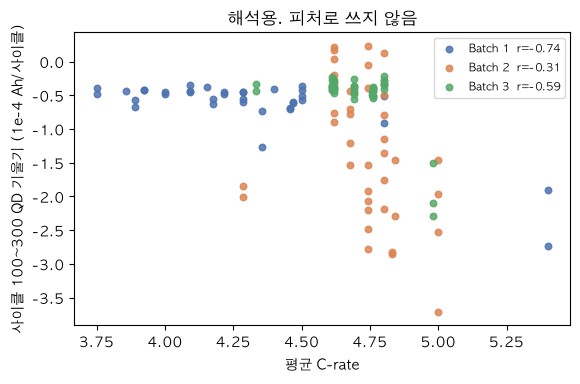

In [20]:
fade_frames = []
for batch_id in (1, 2, 3):
    with (DATA_PROCESSED_DIR / f"batch{batch_id}.pkl").open("rb") as handle:
        summary = pickle.load(handle)["summary"]
    fade_frames.append(summary[summary["cell_id"].isin(set(policy["cell_id"])) & summary["cycle"].between(1, 300)])
fade_summary, _ = correct_summary_spikes(pd.concat(fade_frames, ignore_index=True))
fade_slope = {}
for cell_id, block in fade_summary.groupby("cell_id"):
    window = block.loc[block["cycle"].between(100, 300)]
    x = window["cycle"].to_numpy(dtype=float)
    y = window["QD"].to_numpy(dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    fade_slope[cell_id] = float(np.polyfit(x[ok], y[ok], 1)[0]) if ok.sum() >= 20 else np.nan
policy = policy.copy()
policy["slope_100_300"] = policy["cell_id"].map(fade_slope)
print(f"기울기 결측 {int(policy['slope_100_300'].isna().sum())}")

fig, ax = plt.subplots(figsize=(6.4, 3.8))
for batch_id, color in COLORS.items():
    part = policy.loc[policy["batch"] == batch_id]
    r_value = pearsonr(part["c_avg"], part["slope_100_300"]).statistic
    ax.scatter(part["c_avg"], part["slope_100_300"] * 1e4, s=22, color=color, alpha=0.85, label=f"Batch {batch_id}  r={r_value:.2f}")
    print(f"Batch {batch_id}: Pearson {r_value:+.3f}")
ax.set_xlabel("평균 C-rate")
ax.set_ylabel("사이클 100~300 QD 기울기 (1e-4 Ah/사이클)")
ax.set_title("해석용. 피처로 쓰지 않음")
ax.legend(fontsize=8)
fig.savefig(FIGURES_DIR / "q4_fade_slope.png", dpi=150, bbox_inches="tight")
plt.show()


### 목적
평균 C-rate가 높으면 사이클 100 이후 방전용량이 더 빨리 줄어드는지 본다.

### 결과
사용 셀 119개 모두 사이클 100~300 기울기를 계산했다. 평균 C-rate와의 Pearson은 Batch 1 -0.739, Batch 2 -0.315, Batch 3 -0.586이다. 세 배치 모두 음수다.

### 해석
같은 배치 안에서는 등가 충전 속도가 높을수록 100사이클 이후 용량이 더 가파르게 떨어진다. 초기 100사이클 방전용량에는 거의 안 보이던 열화가 이 구간에서 전류와 맞닿는다. Batch 2의 상관이 가장 약한 것은 수명 분포가 두 덩어리로 갈라져 있기 때문이다.

### 시사점 → 모델링
이 기울기는 사이클 100 이후 정보라 누수다. 피처로 쓰지 않는다. 고속 충전이 중반 열화로 이어진다는 해석에만 쓴다.


## EDA Q5. 상관관계

셀 단위 피처는 `build_feature_table`이 만든다. summary는 초기 100사이클만 쓰고, 단발 스파이크는 함수 안에서 보정한다.
C1, 전환 SOC, C2, 평균 C-rate, 초기 chargetime은 비교용이다. skew는 Q3에서 이미 제외했다.
순위와 잔차, VIF는 Batch 1(36셀)이 기준이고, Batch 2·3는 그 순위와 부호가 유지되는지만 본다.


피처 표 119행, 결측 행 0
                  b1_pearson  b1_spearman  b2_pearson  b3_pearson role
feature                                                               
log10_var             -0.844       -0.826      -0.918      -0.762   후보
log10_abs_min         -0.821       -0.787      -0.901      -0.744   후보
dq_at_2v               0.683        0.655       0.529       0.523   후보
early_ct               0.575        0.432      -0.937       0.600   비교
slope_2_100            0.552        0.473      -0.420       0.433   후보
c_avg                 -0.532       -0.403      -0.038      -0.054   비교
slope_91_100           0.443        0.321       0.269       0.384   후보
dq_skew               -0.434       -0.421      -0.126       0.188   제외
ir_min                 0.345        0.237      -0.361       0.172   후보
c2                    -0.292       -0.161      -0.110      -0.125   비교
qd_max_minus_2         0.263        0.358      -0.313       0.134   후보
c1                    -0.238       -0.237       0.196      

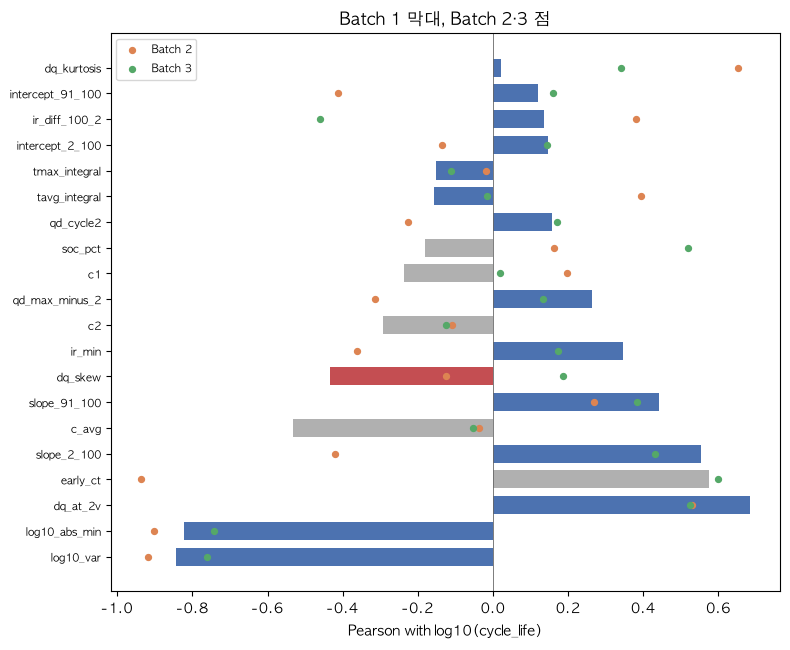

In [21]:
import pickle

import seaborn as sns
from scipy.stats import pearsonr, spearmanr

from src.config import DATA_PROCESSED_DIR
from src.features import (
    COMPARE_FEATURES,
    build_delta_q_table,
    correct_summary_spikes,
    delta_q,
    normalized_delta_q,
    parse_policies,
    summary_features,
    variance_inflation_factors,
)

frames = []
qdlin = {}
vdlin = None
usable = set(cells["cell_id"])
for batch_id in (1, 2, 3):
    with (DATA_PROCESSED_DIR / f"batch{batch_id}.pkl").open("rb") as handle:
        payload = pickle.load(handle)
    summary = payload["summary"]
    frames.append(summary[summary["cell_id"].isin(usable) & summary["cycle"].between(1, 100)])
    for cell_id, grid in payload["qdlin"].items():
        if cell_id in usable:
            qdlin[cell_id] = grid
    if vdlin is None:
        vdlin = payload["vdlin"]
    del payload

summary = pd.concat(frames, ignore_index=True)
corrected, _spike_log = correct_summary_spikes(summary)
feat = build_delta_q_table(cells, qdlin, vdlin)
extra = summary_features(corrected).reset_index()
feat = feat.merge(extra, on="cell_id", how="left")
policies = parse_policies(feat["policy_readable"]).drop(columns=["newstructure"])
feat = feat.join(policies)
norm_var = []
for record in feat.itertuples(index=False):
    curve = normalized_delta_q(delta_q(qdlin[record.cell_id]), record.qd_cycle10)
    variance = float(np.var(curve, ddof=1))
    norm_var.append(float(np.log10(variance)) if variance > 0 else np.nan)
feat["log10_var_norm"] = norm_var
feat["log_life"] = np.log10(feat["cycle_life"])
# 순위·VIF·잔차는 잠긴 MODEL_FEATURES 2개가 아니라, 이 노트북에 저장된 후보 열로 계산한다.
CANDIDATE_FEATURES = (
    "log10_var",
    "log10_abs_min",
    "dq_at_2v",
    "slope_2_100",
    "dq_skew",
    "slope_91_100",
    "intercept_2_100",
    "intercept_91_100",
    "qd_cycle2",
    "qd_max_minus_2",
    "ir_min",
    "ir_diff_100_2",
    "tmax_integral",
    "tavg_integral",
    "dq_kurtosis",
)
feature_cols = list(CANDIDATE_FEATURES) + list(COMPARE_FEATURES)
print(f"피처 표 {feat.shape[0]}행, 결측 행 {int(feat[feature_cols].isna().any(axis=1).sum())}")

def correlation_rows(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for name in feature_cols:
        rows.append(
            {
                "feature": name,
                "pearson": pearsonr(frame[name], frame["log_life"]).statistic,
                "spearman": spearmanr(frame[name], frame["log_life"]).statistic,
            }
        )
    return pd.DataFrame(rows).set_index("feature")

by_batch = {batch_id: correlation_rows(part) for batch_id, part in feat.groupby("batch")}
rank = by_batch[1][["pearson", "spearman"]].rename(columns={"pearson": "b1_pearson", "spearman": "b1_spearman"})
rank["b2_pearson"] = by_batch[2]["pearson"]
rank["b3_pearson"] = by_batch[3]["pearson"]
rank["role"] = "후보"
rank.loc[rank.index.isin(COMPARE_FEATURES), "role"] = "비교"
rank.loc["dq_skew", "role"] = "제외"
rank = rank.sort_values("b1_pearson", key=lambda column: column.abs(), ascending=False)
print(rank.round(3).to_string())

role_color = {"후보": "#4C72B0", "비교": "#B0B0B0", "제외": "#C44E52"}
fig, ax = plt.subplots(figsize=(8, 6.6))
positions = np.arange(len(rank))
ax.barh(positions, rank["b1_pearson"], color=[role_color[role] for role in rank["role"]], height=0.7)
ax.scatter(rank["b2_pearson"], positions, s=18, color="#DD8452", zorder=3, label="Batch 2")
ax.scatter(rank["b3_pearson"], positions, s=18, color="#55A868", zorder=3, label="Batch 3")
ax.axvline(0, color="0.4", lw=0.6)
ax.set_yticks(positions)
ax.set_yticklabels(rank.index, fontsize=8)
ax.set_xlabel("Pearson with log10(cycle_life)")
ax.set_title("Batch 1 막대, Batch 2·3 점")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "q5_corr_rank.png", dpi=150, bbox_inches="tight")
plt.show()


### 목적
어떤 피처가 Batch 1의 log 수명과 함께 움직이고, 그 순위와 부호가 Batch 2·3에서도 남는지 본다.

### 결과
Batch 1 1위는 log10(var(ΔQ))로 Pearson -0.844, Spearman -0.826이다. 2위 log10(|min|)은 -0.821, 3위 2V 값은 +0.683이다. 이 셋은 Batch 2·3에서도 부호가 같다. log10(var)는 Batch 2 -0.918, Batch 3 -0.762다.

비교용 초기 chargetime은 Batch 1에서 +0.575로 4위지만 Batch 2에서 -0.937로 부호가 뒤집힌다. 평균 C-rate는 -0.532에서 Batch 2 -0.038, Batch 3 -0.054로 사라진다. 사이클 2~100 QD 기울기도 +0.552에서 Batch 2 -0.420으로 뒤집힌다. kurtosis는 Batch 1 +0.022인데 Batch 2는 +0.653이다. skew는 Batch 1 -0.434로 이미 제외한 수준보다 약하지는 않지만, Batch 3에서 +0.188로 부호가 바뀐다.

### 해석
세 배치에서 부호가 유지되는 강한 신호는 ΔQ 곡선의 크기뿐이고, 그 크기는 분산과 최솟값, 2V 값에 같이 들어 있다. 충전 조건과 초기 용량 기울기는 학습 배치의 순위가 테스트에서 유지되지 않는다. 같은 배치 안에서는 고속 충전이 수명을 줄여도, 그 조건 변수를 다른 배치에 가져가면 수명을 가리키지 못한다.

### 시사점 → 모델링
메인 후보는 ΔQ 분산으로 좁힌다. 정책·chargetime·초기 기울기는 비교용으로만 남기고 모델에 넣지 않는다. 2V 값과 log10(|min|)은 순위가 높아도 분산과 같은 정보인지 다음 공선성에서 가른다.


|r| > 0.8
log10_var            log10_abs_min        +0.996
log10_var            dq_at_2v             -0.885
log10_abs_min        dq_at_2v             -0.903
dq_at_2v             slope_2_100          +0.824
dq_at_2v             dq_skew              -0.847
slope_2_100          slope_91_100         +0.891
intercept_2_100      intercept_91_100     +0.974
intercept_2_100      qd_cycle2            +0.999
intercept_91_100     qd_cycle2            +0.969
tmax_integral        tavg_integral        +0.953

VIF, 후보 전체
intercept_2_100     12368.0
intercept_91_100    10479.9
slope_91_100         2480.4
qd_cycle2            2118.2
slope_2_100          1350.3
log10_abs_min         710.7
log10_var             689.2
dq_at_2v               39.2
qd_max_minus_2         31.8
tavg_integral          29.9
tmax_integral          26.9
dq_skew                15.1
dq_kurtosis             6.6
ir_diff_100_2           3.7
ir_min                  3.4

핵심 쌍 상관
                log10_var  log10_abs_min  dq_at_2v  qd_max_

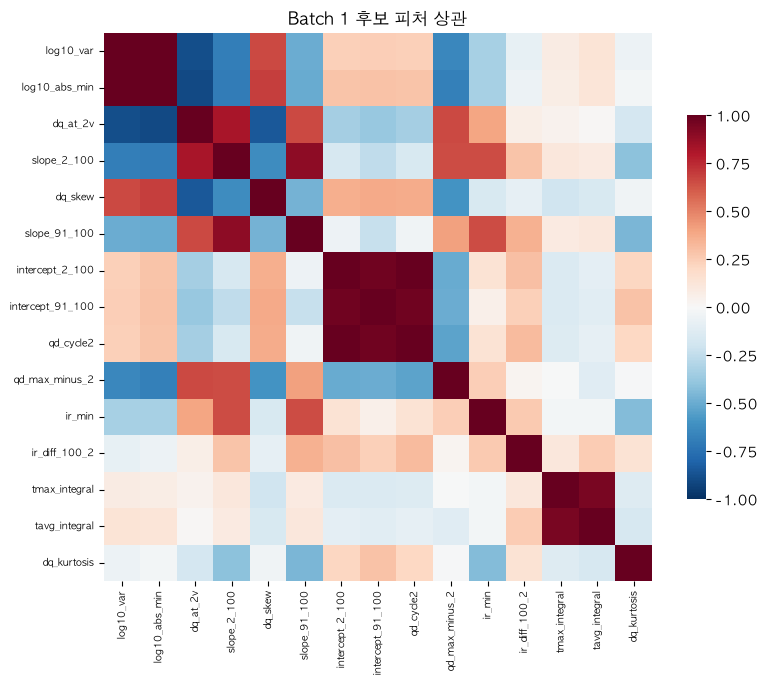

In [22]:
batch1 = feat.loc[feat["batch"] == 1]
model_corr = batch1[list(CANDIDATE_FEATURES)].corr()
print("|r| > 0.8")
for left_index, left in enumerate(CANDIDATE_FEATURES):
    for right in list(CANDIDATE_FEATURES)[left_index + 1 :]:
        value = model_corr.loc[left, right]
        if abs(value) > 0.8:
            print(f"{left:20} {right:20} {value:+.3f}")

print("\nVIF, 후보 전체")
print(variance_inflation_factors(batch1[list(CANDIDATE_FEATURES)]).round(1).to_string())
pair = batch1[["log10_var", "log10_abs_min", "dq_at_2v", "qd_max_minus_2"]]
print("\n핵심 쌍 상관")
print(pair.corr().round(3).to_string())

fig, ax = plt.subplots(figsize=(8.2, 6.8))
sns.heatmap(
    model_corr,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"shrink": 0.7},
)
ax.tick_params(axis="both", labelsize=7)
ax.set_title("Batch 1 후보 피처 상관")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "q5_corr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


### 목적
순위가 높은 피처가 서로 같은 정보인지, 그래서 하나만 남길 수 있는지 본다.

### 결과
Batch 1에서 log10(var)와 log10(|min|)의 상관은 0.996이다. 둘의 VIF는 후보를 같이 넣으면 각각 689, 711이다. 2V 값도 log10(var)와 -0.885다. 사이클 2~100 절편과 사이클 2 QD는 0.999, 두 절편끼리는 0.974다. Tmax 적분과 Tavg 적분은 0.953이다. 기울기 두 구간도 0.891이다.

### 해석
최솟값과 2V 값은 분산과 다른 물리량이 아니다. 곡선이 깊어지면 분산, 최솟값의 절댓값, 2V 근처 값이 함께 커진다. 용량 곡선의 절편은 사이클 2의 QD를 다시 적은 것이고, 온도 두 적분은 같은 열을 다른 이름으로 적은 것이다. 36셀에서 이 쌍을 같이 넣으면 계수가 서로 자리를 바꾼다.

### 시사점 → 모델링
**log10(var(ΔQ))를 남기고 log10(|min ΔQ|)는 빼는 것으로 정한다.** 2V 값, 용량 절편, 온도 적분 쌍, 두 구간의 기울기 쌍도 각각 하나만 둘 수 있고, 그마저 분산과 겹치면 잔차에서 탈락시킨다.


                     b1     b2     b3 role
feature                                   
qd_cycle2         0.667  0.201  0.512   후보
intercept_2_100   0.645  0.219  0.477   후보
intercept_91_100  0.616 -0.126  0.469   후보
qd_max_minus_2   -0.529 -0.631 -0.427   후보
dq_skew           0.223  0.344  0.059   제외
tmax_integral    -0.147 -0.159 -0.184   후보
soc_pct          -0.134  0.007  0.300   비교
ir_diff_100_2     0.119 -0.175  0.052   후보
dq_at_2v         -0.118 -0.410 -0.057   후보
ir_min            0.116 -0.190  0.245   후보
c_avg            -0.106  0.209  0.025   비교
early_ct          0.095 -0.165  0.291   비교
c2               -0.082  0.213  0.034   비교
tavg_integral    -0.072  0.049 -0.128   후보
slope_2_100      -0.054 -0.661 -0.018   후보
dq_kurtosis      -0.051  0.497 -0.089   후보
c1                0.041  0.101 -0.183   비교
slope_91_100      0.040  0.065  0.051   후보
log10_abs_min     0.036  0.034 -0.121   후보
log10(var)만의 Batch 1 R² 0.712


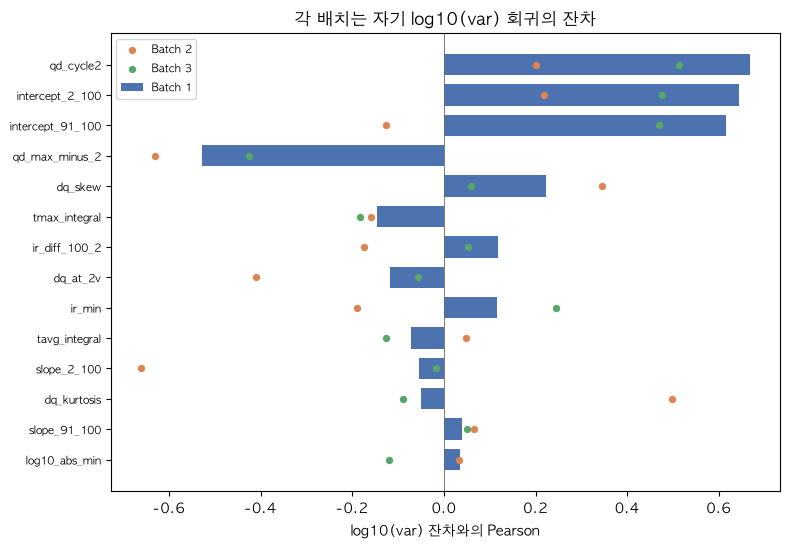

In [23]:
def batch_residual(frame: pd.DataFrame) -> pd.Series:
    slope, intercept = np.polyfit(frame["log10_var"], frame["log_life"], 1)
    return frame["log_life"] - (slope * frame["log10_var"] + intercept)

residual_names = [name for name in feature_cols if name != "log10_var"]
residual_rows = []
for name in residual_names:
    row = {"feature": name}
    for batch_id, part in feat.groupby("batch"):
        row[f"b{batch_id}"] = pearsonr(part[name], batch_residual(part)).statistic
    residual_rows.append(row)
residual = pd.DataFrame(residual_rows).set_index("feature")
residual["role"] = rank["role"]
residual = residual.sort_values("b1", key=lambda column: column.abs(), ascending=False)
print(residual.round(3).to_string())
print(
    "log10(var)만의 Batch 1 R² "
    f"{1 - np.sum(batch_residual(batch1) ** 2) / np.sum((batch1['log_life'] - batch1['log_life'].mean()) ** 2):.3f}"
)

plot_residual = residual.loc[residual["role"] != "비교"].iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5.6))
positions = np.arange(len(plot_residual))
ax.barh(positions, plot_residual["b1"], color="#4C72B0", height=0.7, label="Batch 1")
ax.scatter(plot_residual["b2"], positions, s=18, color="#DD8452", zorder=3, label="Batch 2")
ax.scatter(plot_residual["b3"], positions, s=18, color="#55A868", zorder=3, label="Batch 3")
ax.axvline(0, color="0.4", lw=0.6)
ax.set_yticks(positions)
ax.set_yticklabels(plot_residual.index, fontsize=8)
ax.set_xlabel("log10(var) 잔차와의 Pearson")
ax.set_title("각 배치는 자기 log10(var) 회귀의 잔차")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "q5_residual.png", dpi=150, bbox_inches="tight")
plt.show()


### 목적
log10(var(ΔQ))로 로그 수명을 맞춘 뒤에 남는 잔차와 상관 있는 피처가 있는지, 그 상관이 다른 배치에도 있는지 본다.

### 결과
Batch 1에서 log10(var)만의 R²는 0.712다. 잔차와 가장 큰 상관은 사이클 2 QD +0.667, 사이클 2~100 절편 +0.645, 사이클 91~100 절편 +0.616인데, 이 셋은 서로 상관이 0.97 이상이라 한 정보다.

그다음이 사이클 2~100 QD 최댓값에서 사이클 2 QD를 뺀 값으로, Batch 1 잔차와 -0.529, Batch 2 -0.631, Batch 3 -0.427이다. 잔차와의 부호는 세 배치에서 같다. 수명과의 단순 상관은 Batch 1 +0.263, Batch 2 -0.313으로 부호가 바뀐다. log10(var)와의 상관은 -0.648이라 VIF는 1.73이다. Batch 1에서 이 값의 범위는 0.003~0.010Ah다. 둘을 같이 넣은 in-sample R²는 0.851이다. 교차검증 값이 아니다.

사이클 2 QD와 초반 절편의 Batch 2 잔차는 +0.20 근처이고, 후반 절편은 -0.13으로 부호가 바뀐다. log10(|min|)의 잔차 상관은 0.036이다. 2V 값은 -0.118, 온도 적분은 -0.15 이하다. 초기 기울기의 잔차 상관은 Batch 1에서 -0.054지만 Batch 2에서는 -0.661로, 배치마다 다른 나머지를 설명한다.

### 해석
분산이 잡은 뒤에도 수명과 남는 신호는 초기 방전용량이 사이클 2보다 얼마나 더 올라갔는지다. 많이 올라간 셀은 같은 분산의 동료보다 수명이 짧다. 폭이 수 mAh라 용량 수준 그 자체는 아니고, 초반에 용량이 조금 솟는 정도다. 사이클 2의 QD 높이는 Batch 1 잔차와는 커 보여도 Batch 2로 가면 거의 남지 않는다. 절편은 그 높이를 다시 적은 것이다.

### 시사점 → 모델링
추가 후보는 `qd_max_minus_2` 하나다. 2V 값, 최솟값, 온도, IR, 기울기는 잔차를 설명하지 못하거나 배치에서 부호가 바뀐다.


원본 ΔQ Batch 1 n=26 3.0V -0.0312 최솟값 -0.0352
원본 ΔQ Batch 2 n=7 3.0V -0.0209 최솟값 -0.0217
원본 ΔQ Batch 3 n=28 3.0V -0.0241 최솟값 -0.0265
사이클 10 QD로 나눈 ΔQ Batch 1 n=26 3.0V -0.0289 최솟값 -0.0323
사이클 10 QD로 나눈 ΔQ Batch 2 n=7 3.0V -0.0192 최솟값 -0.0199
사이클 10 QD로 나눈 ΔQ Batch 3 n=28 3.0V -0.0225 최솟값 -0.0248


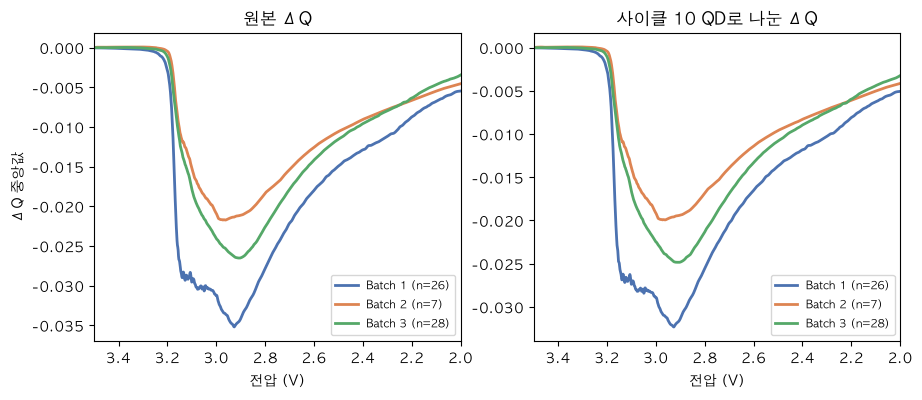

사이클 10 QD 중앙 batch
1    1.0819
2    1.0984
3    1.0684
수명 700–1,100 log10(var) 중앙 차이 Batch1−Batch3: 원본 0.271, 정규화 0.253


In [24]:
band = feat.loc[feat["cycle_life"].between(700, 1100)]
voltage_index = int(np.argmin(np.abs(vdlin - 3.0)))
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.0), sharey=False)
for ax, normalize, title in (
    (axes[0], False, "원본 ΔQ"),
    (axes[1], True, "사이클 10 QD로 나눈 ΔQ"),
):
    for batch_id, color in COLORS.items():
        chosen = band.loc[band["batch"] == batch_id]
        curves = []
        for record in chosen.itertuples(index=False):
            curve = delta_q(qdlin[record.cell_id])
            if normalize:
                curve = normalized_delta_q(curve, record.qd_cycle10)
            curves.append(curve)
        median_curve = np.median(np.vstack(curves), axis=0)
        print(
            f"{title} Batch {batch_id} n={len(chosen)} "
            f"3.0V {median_curve[voltage_index]:.4f} 최솟값 {median_curve.min():.4f}"
        )
        ax.plot(vdlin, median_curve, color=color, lw=2, label=f"Batch {batch_id} (n={len(chosen)})")
    ax.set_xlim(3.5, 2.0)
    ax.set_xlabel("전압 (V)")
    ax.set_title(title)
    ax.legend(fontsize=8)
axes[0].set_ylabel("ΔQ 중앙값")
fig.savefig(FIGURES_DIR / "q5_norm_delta.png", dpi=150, bbox_inches="tight")
plt.show()
print("사이클 10 QD 중앙", feat.groupby("batch")["qd_cycle10"].median().round(4).to_string())
print(
    "수명 700–1,100 log10(var) 중앙 차이 Batch1−Batch3: 원본 "
    f"{band.loc[band.batch==1, 'log10_var'].median() - band.loc[band.batch==3, 'log10_var'].median():.3f}, "
    "정규화 "
    f"{band.loc[band.batch==1, 'log10_var_norm'].median() - band.loc[band.batch==3, 'log10_var_norm'].median():.3f}"
)


### 목적
ΔQ를 사이클 10 방전용량으로 나누면, 같은 수명대에서 Batch 1의 골이 더 깊은 오프셋이 줄어드는지 본다.

### 결과
수명 700~1,100의 3.0V 중앙 ΔQ는 원본이 Batch 1 -0.0312Ah, Batch 3 -0.0241Ah다. 차이는 0.0072Ah, 비는 1.30이다. 사이클 10 QD로 나누면 -0.0289와 -0.0225, 차이 0.0064, 비 1.29다. log10(var) 중앙의 Batch 1−Batch 3 차이도 0.271에서 0.253으로만 줄어든다. 사이클 10 QD 중앙은 Batch 1이 1.082Ah, Batch 2가 1.098Ah, Batch 3이 1.068Ah다.

### 해석
나누는 용량이 배치마다 거의 같다. 그래서 정규화는 곡선 전체에 비슷한 배율을 곱할 뿐, 배치 사이에 골 깊이 비율을 맞추지 못한다. 오프셋은 방전용량 수준이 아니라 Qdlin이 잡힌 전압 구간이 다른 데서 온다.

### 시사점 → 모델링
정규화 ΔQ는 피처로 쓰지 않는다. 배치 오프셋은 Q3에서 적은 대로 Gap(Valid-Test)의 예상 원인으로 남긴다.

**제안(미확정):** 메인 모델 피처는 2개다. `log10(var(ΔQ))`와 `qd_max_minus_2`(사이클 2~100 방전용량 최댓값 − 사이클 2)다. 두 번째는 단순 상관의 부호는 배치마다 다르고, log10(var)를 뺀 잔차에서만 부호가 같다. 학습 셀이 36개라 3개 이상으로 늘리지 않는다. 다음 후보는 분산과 상관이 0.99이거나, 잔차 상관이 0.15 미만이거나, Batch 2에서 부호가 바뀐다. 2개를 넣은 R² 0.85는 Batch 1 전체 적합이라 교차검증이 아니다. 확정은 별도로 한다.
